In [ ]:

import json
results_oc_calcs = {}
datasets = set()
with open('results/xgb_oc_calcs_pt2.txt', 'r') as file:
    for line in file:
        if not line.startswith('{'):
            continue
        line_dict = json.loads(line.strip())
        key = f"{line_dict['dname']}_{line_dict['params']['n_estimators']}_{line_dict['params']['max_depth']}_{line_dict['params']['learning_rate']}_{line_dict['fold']}"
        results_oc_calcs[key] = line_dict
        datasets.add(line_dict['dname'])

In [ ]:
# collecting the results
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

df = []
for d in datasets:
    keys = [k for k in results_oc_calcs.keys() if k.split('_')[0] == d]
    
    for i, k in enumerate(keys):
        # print(k)
        # print(results_oc_calcs[k])
        oc_bound_leafs = results_oc_calcs[k]['bound_oc_space'][1]
        oc_bound_features = results_oc_calcs[k]['bound_oc_space'][0]
        ver_time = results_oc_calcs[k]['verifications']["exact_emp_rob_time"]
        ver_timeout = results_oc_calcs[k]['verifications']["exact_emp_rob_timeout"]
        robustness = results_oc_calcs[k]['verifications']["exact_emp_rob"]

        nb_trees = results_oc_calcs[k]['params']['n_estimators']
        max_depth = results_oc_calcs[k]['params']['max_depth']
        learning_rate = results_oc_calcs[k]['params']['learning_rate']

        oc_score_training_1 = 1/2 * results_oc_calcs[k]['oc_score_training']['0']['oc_score_k1'] + 1/2 * results_oc_calcs[k]['oc_score_training']['1']['oc_score_k1']
        oc_score_test_1 = 1/2 * results_oc_calcs[k]['oc_score_test']['0']['oc_score_k1'] + 1/2 * results_oc_calcs[k]['oc_score_test']['1']['oc_score_k1']

        oc_score_training_100 = 1/2 * results_oc_calcs[k]['oc_score_training']['0']['oc_score_k100'] + 1/2 * results_oc_calcs[k]['oc_score_training']['1']['oc_score_k100']
        oc_score_test_100 = 1/2 * results_oc_calcs[k]['oc_score_test']['0']['oc_score_k100'] + 1/2 * results_oc_calcs[k]['oc_score_test']['1']['oc_score_k100']

        observed_oc_space_training = results_oc_calcs[k]['observed_oc_space_training']
        observed_oc_space_test = results_oc_calcs[k]['observed_oc_space_test']

        df.append([d, oc_bound_leafs, oc_bound_features, ver_time, ver_timeout, robustness, nb_trees, max_depth, learning_rate, oc_score_training_1, oc_score_test_1, oc_score_training_100, oc_score_test_100, observed_oc_space_training, observed_oc_space_test])

df = pd.DataFrame(df, columns=['dname', 'oc_bound_leafs', 'oc_bound_features', 'ver_time', 'ver_timeout', 'robustness', 'nb_trees', 'max_depth', 'learning_rate', 'oc_score_training_1', 'oc_score_test_1', 'oc_score_training_100', 'oc_score_test_100', 'observed_oc_space_training', 'observed_oc_space_test'])

In [ ]:
df = []
for d in datasets:
    keys = [k for k in results_oc_calcs.keys() if k.split('_')[0] == d]
    
    for i, k in enumerate(keys):
        lop_refinement = results_oc_calcs[k]['refinements'][3]
        # print(lop_refinement)
        oc_bound_leafs = lop_refinement['bound_oc_space'][1]
        oc_bound_features = lop_refinement['bound_oc_space'][0]
        ver_time = lop_refinement['verifications']["exact_emp_rob_time"]
        ver_timeout = lop_refinement['verifications']["exact_emp_rob_timeout"]
        robustness = lop_refinement['verifications']["exact_emp_rob"]

        nb_trees = results_oc_calcs[k]['params']['n_estimators']
        max_depth = results_oc_calcs[k]['params']['max_depth']
        learning_rate = results_oc_calcs[k]['params']['learning_rate']

        oc_score_training = 1/2 * lop_refinement['oc_score_training']['0']['oc_score_k1'] + 1/2 * lop_refinement['oc_score_training']['1']['oc_score_k1']
        oc_score_test = 1/2 * lop_refinement['oc_score_test']['0']['oc_score_k1'] + 1/2 * lop_refinement['oc_score_test']['1']['oc_score_k1']

        observed_oc_space_training = lop_refinement['observed_oc_space_training']
        observed_oc_space_test = lop_refinement['observed_oc_space_test']

        df.append([d, oc_bound_leafs, oc_bound_features, ver_time, ver_timeout, robustness, nb_trees, max_depth, learning_rate, oc_score_training, oc_score_test, observed_oc_space_training, observed_oc_space_test])

df = pd.DataFrame(df, columns=['dname', 'oc_bound_leafs', 'oc_bound_features', 'ver_time', 'ver_timeout', 'robustness', 'nb_trees', 'max_depth', 'learning_rate', 'oc_score_training', 'oc_score_test', 'observed_oc_space_training', 'observed_oc_space_test'])

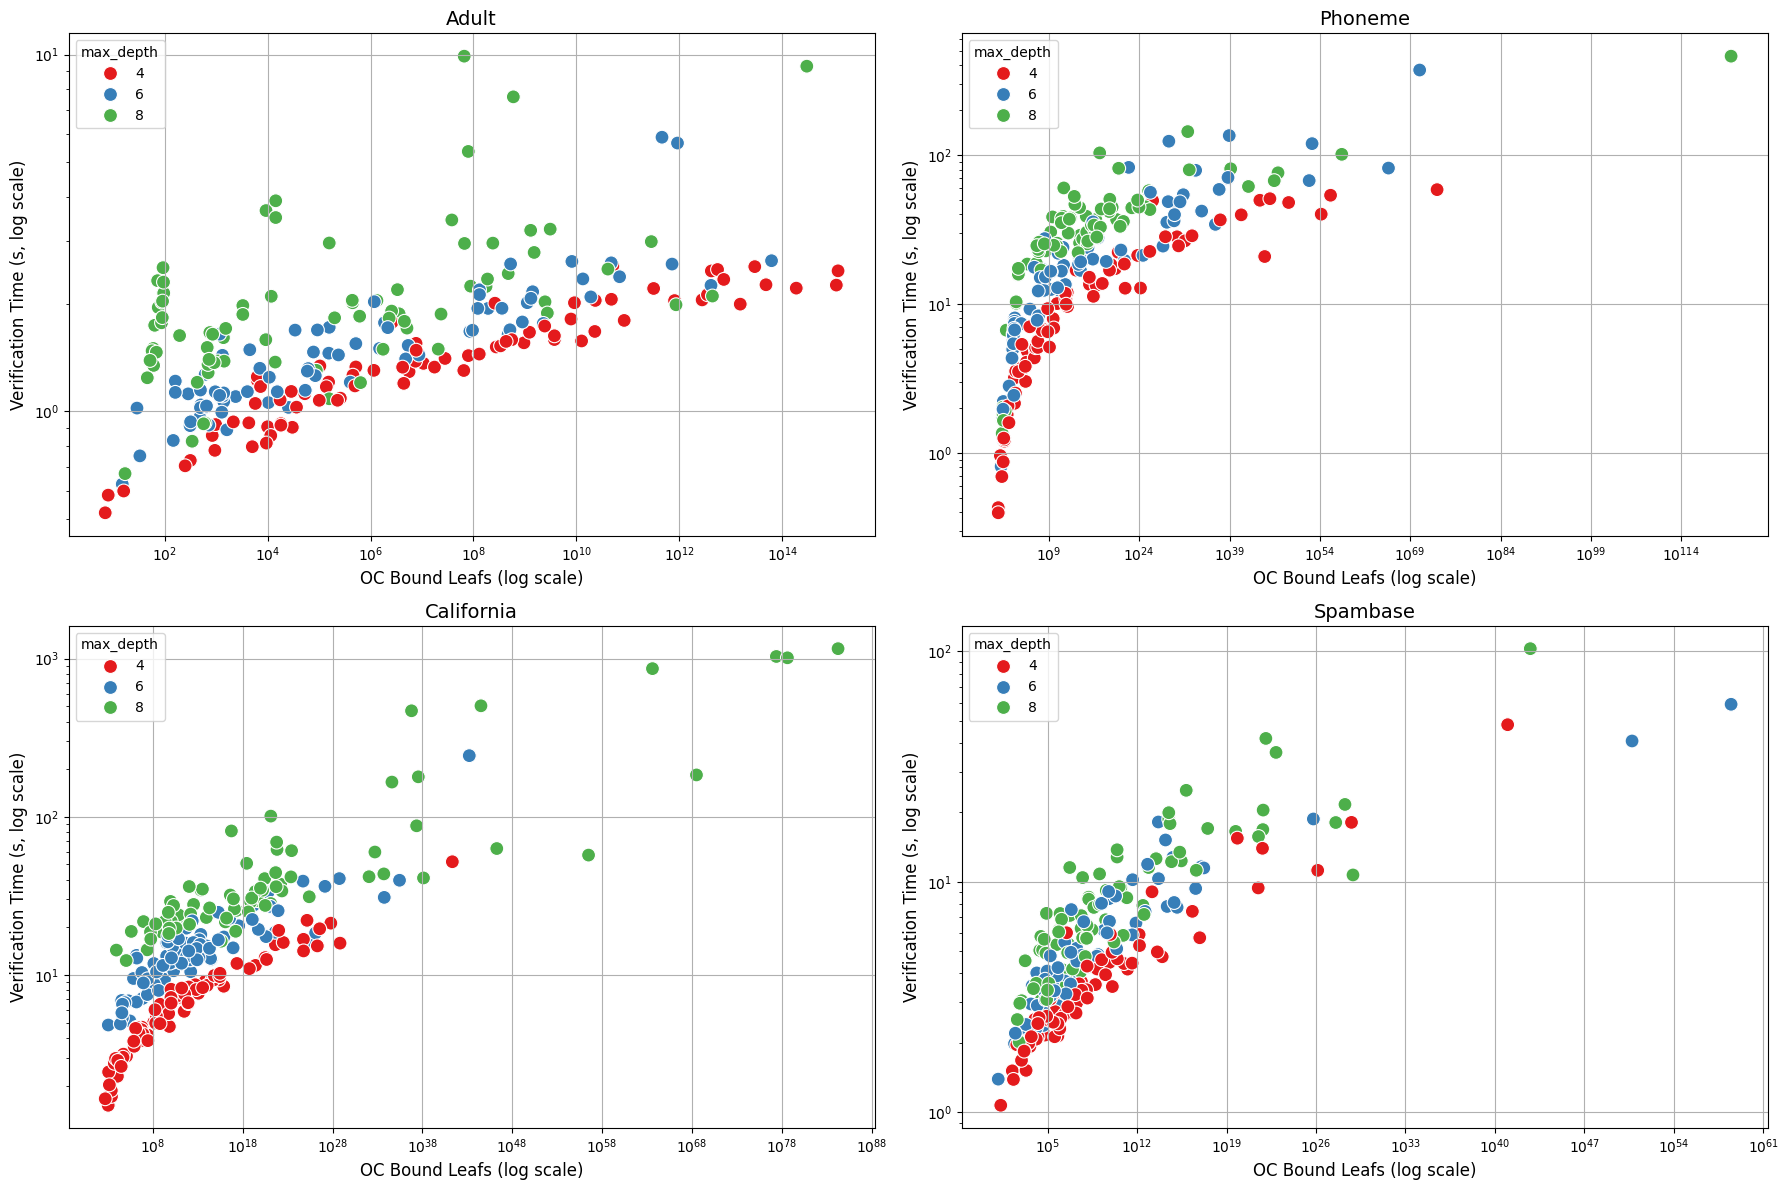

In [ ]:
import seaborn as sns

# Plot oc bound leafs vs verification time per dataset
import matplotlib.pyplot as plt

# Get unique datasets
unique_datasets = df['dname'].unique()
n_datasets = len(unique_datasets)

# Create subplots
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()

for i, dataset in enumerate(unique_datasets):
    if i < len(axes):
        dataset_df = df[df['dname'] == dataset]
        
        sns.scatterplot(x='oc_bound_leafs', y='ver_time', hue='max_depth', data=dataset_df, 
                   s=100, ax=axes[i], palette='Set1')
        axes[i].set_xscale('log')
        axes[i].set_yscale('log')
        axes[i].set_xlabel('OC Bound Leafs (log scale)', fontsize=12)
        axes[i].set_ylabel('Verification Time (s, log scale)', fontsize=12)
        axes[i].set_title(f'{dataset}', fontsize=14)
        axes[i].grid(True)

# Hide unused subplots
for i in range(n_datasets, len(axes)):
    axes[i].axis('off')

plt.tight_layout()
plt.savefig('plots/oc_bound_leafs_vs_ver_time_per_dataset.png', dpi=300)
plt.show()

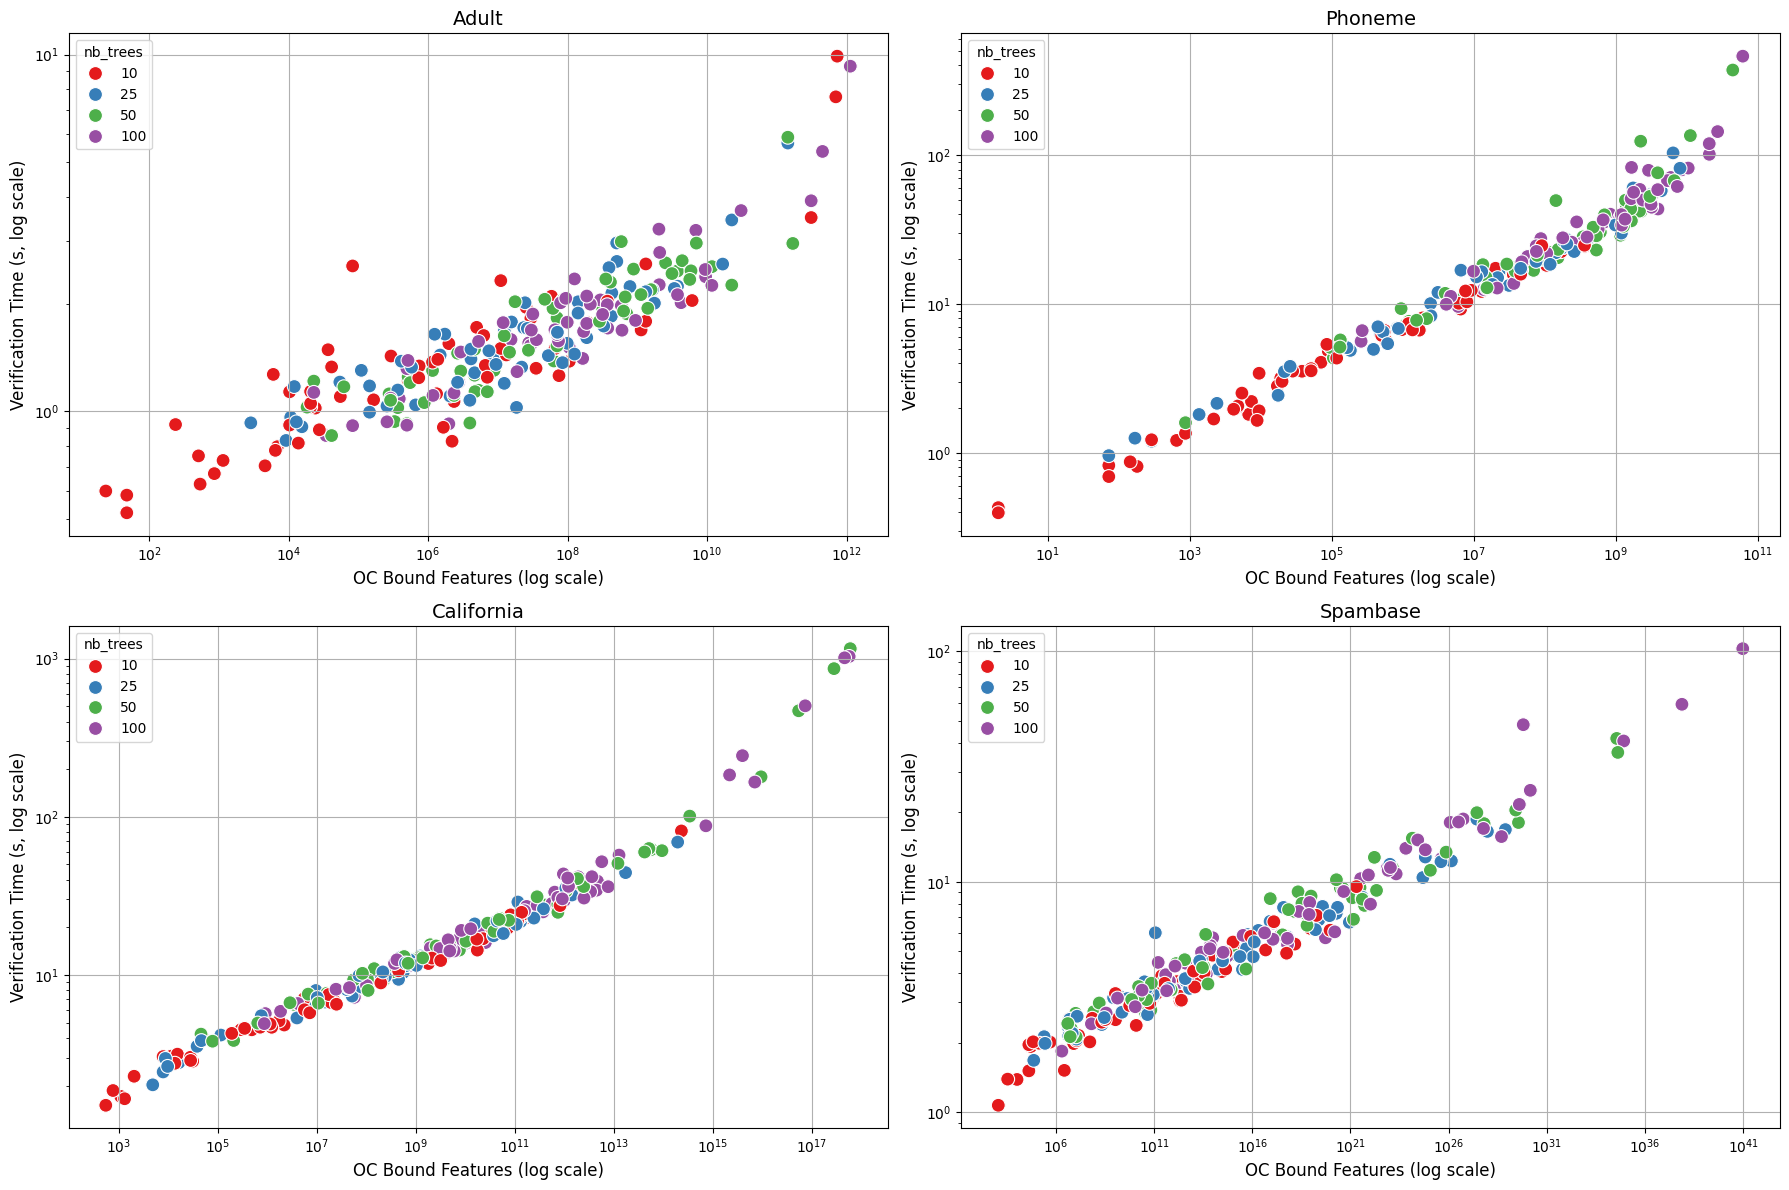

In [ ]:
# Plot oc bound features vs verification time per dataset
import matplotlib.pyplot as plt

# Get unique datasets
unique_datasets = df['dname'].unique()
n_datasets = len(unique_datasets)

# Create subplots
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()

for i, dataset in enumerate(unique_datasets):
    if i < len(axes):
        dataset_df = df[df['dname'] == dataset]
        
        sns.scatterplot(x='oc_bound_features', y='ver_time', hue='nb_trees', data=dataset_df, 
                       s=100, ax=axes[i], palette='Set1')
        axes[i].set_xscale('log')
        axes[i].set_yscale('log')
        axes[i].set_xlabel('OC Bound Features (log scale)', fontsize=12)
        axes[i].set_ylabel('Verification Time (s, log scale)', fontsize=12)
        axes[i].set_title(f'{dataset}', fontsize=14)
        axes[i].grid(True)

# Hide unused subplots
for i in range(n_datasets, len(axes)):
    axes[i].axis('off')

plt.tight_layout()
plt.savefig('plots/oc_bound_features_vs_ver_time_per_dataset.png', dpi=300)
plt.show()

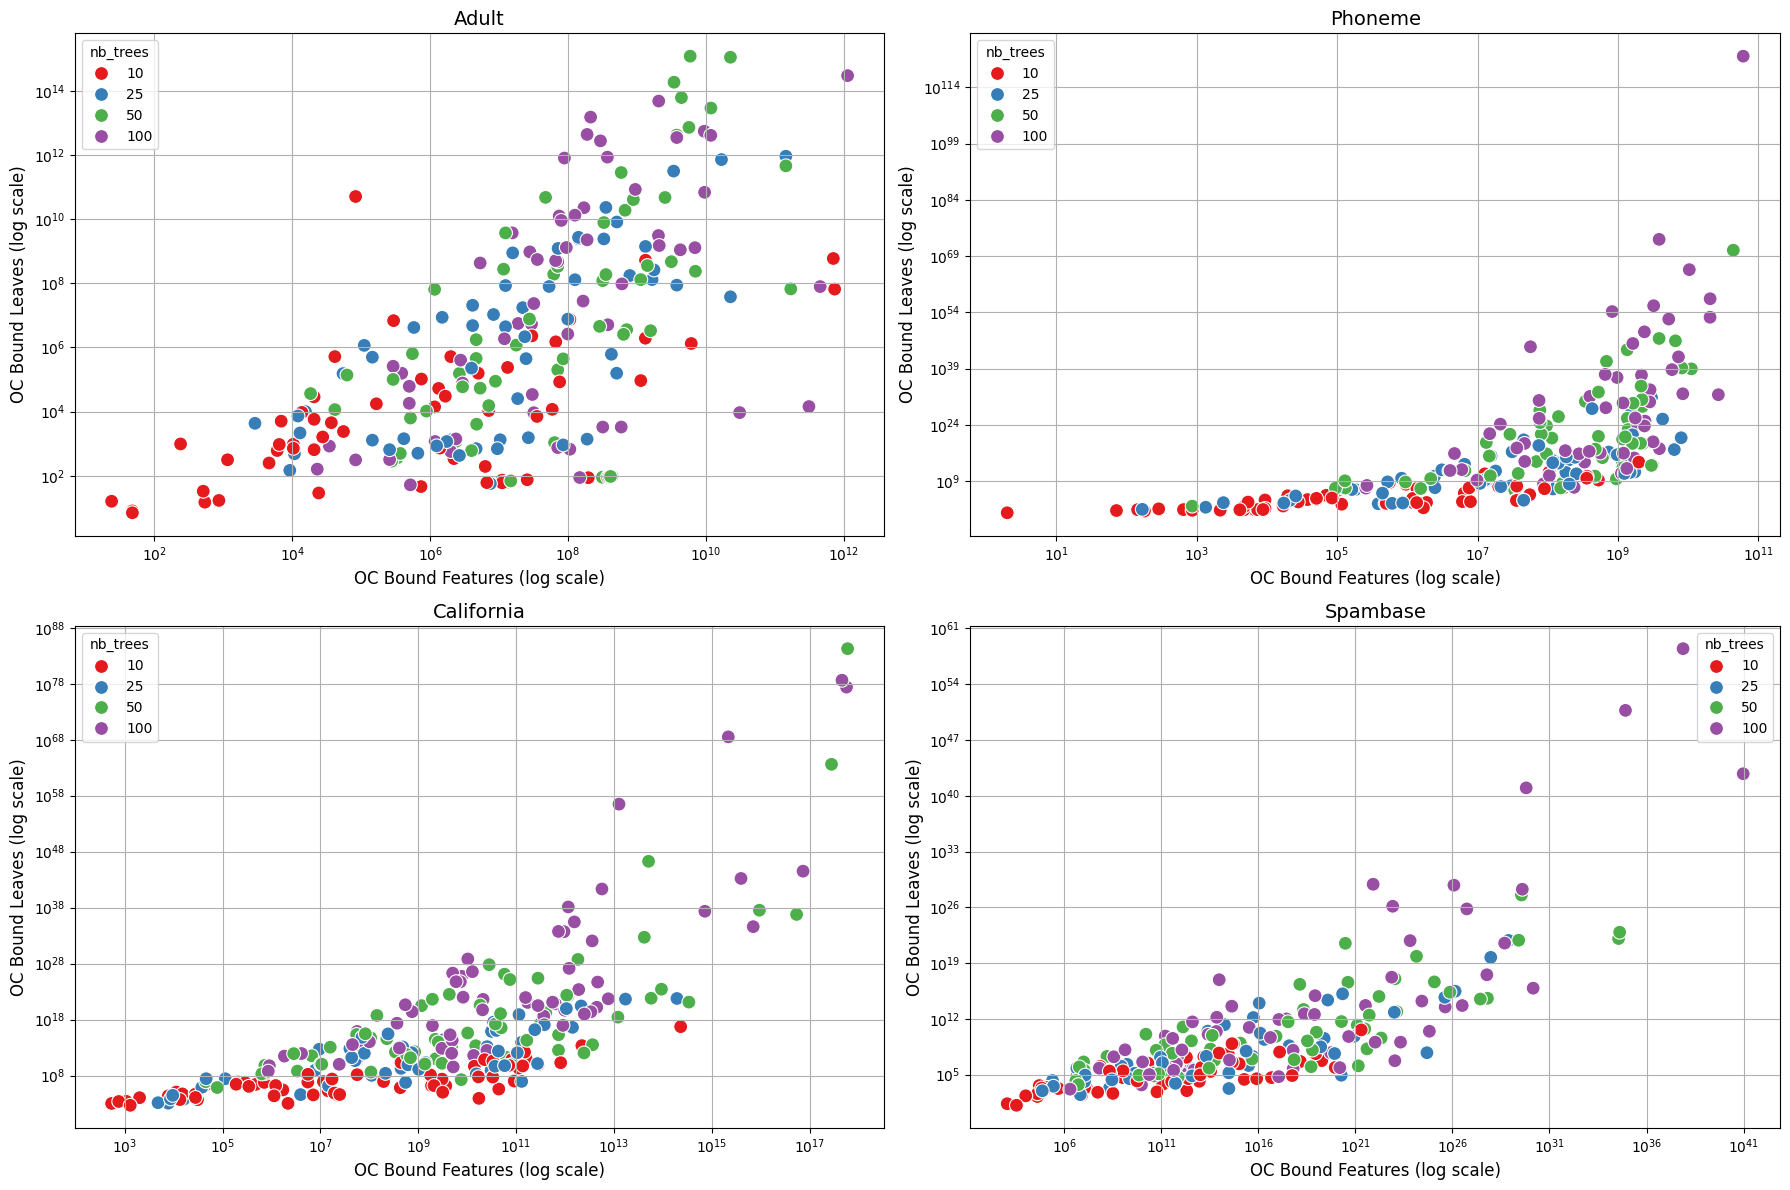

In [ ]:
# Plot the OC bound leafs vs OC bound features per dataset
import matplotlib.pyplot as plt

# Get unique datasets
unique_datasets = df['dname'].unique()
n_datasets = len(unique_datasets)

# Create subplots
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()

for i, dataset in enumerate(unique_datasets):
    if i < len(axes):
        dataset_df = df[df['dname'] == dataset]

        sns.scatterplot(x='oc_bound_features', y='oc_bound_leafs', hue='nb_trees', data=dataset_df,
                       s=100, ax=axes[i], palette='Set1')
        axes[i].set_xscale('log')
        axes[i].set_yscale('log')
        axes[i].set_xlabel('OC Bound Features (log scale)', fontsize=12)
        axes[i].set_ylabel('OC Bound Leaves (log scale)', fontsize=12)
        axes[i].set_title(f'{dataset}', fontsize=14)
        axes[i].grid(True)

# Hide unused subplots
for i in range(n_datasets, len(axes)):
    axes[i].axis('off')

plt.tight_layout()
plt.savefig('plots/oc_bound_features_vs_oc_bound_leaves_per_dataset.png', dpi=300)
plt.show()


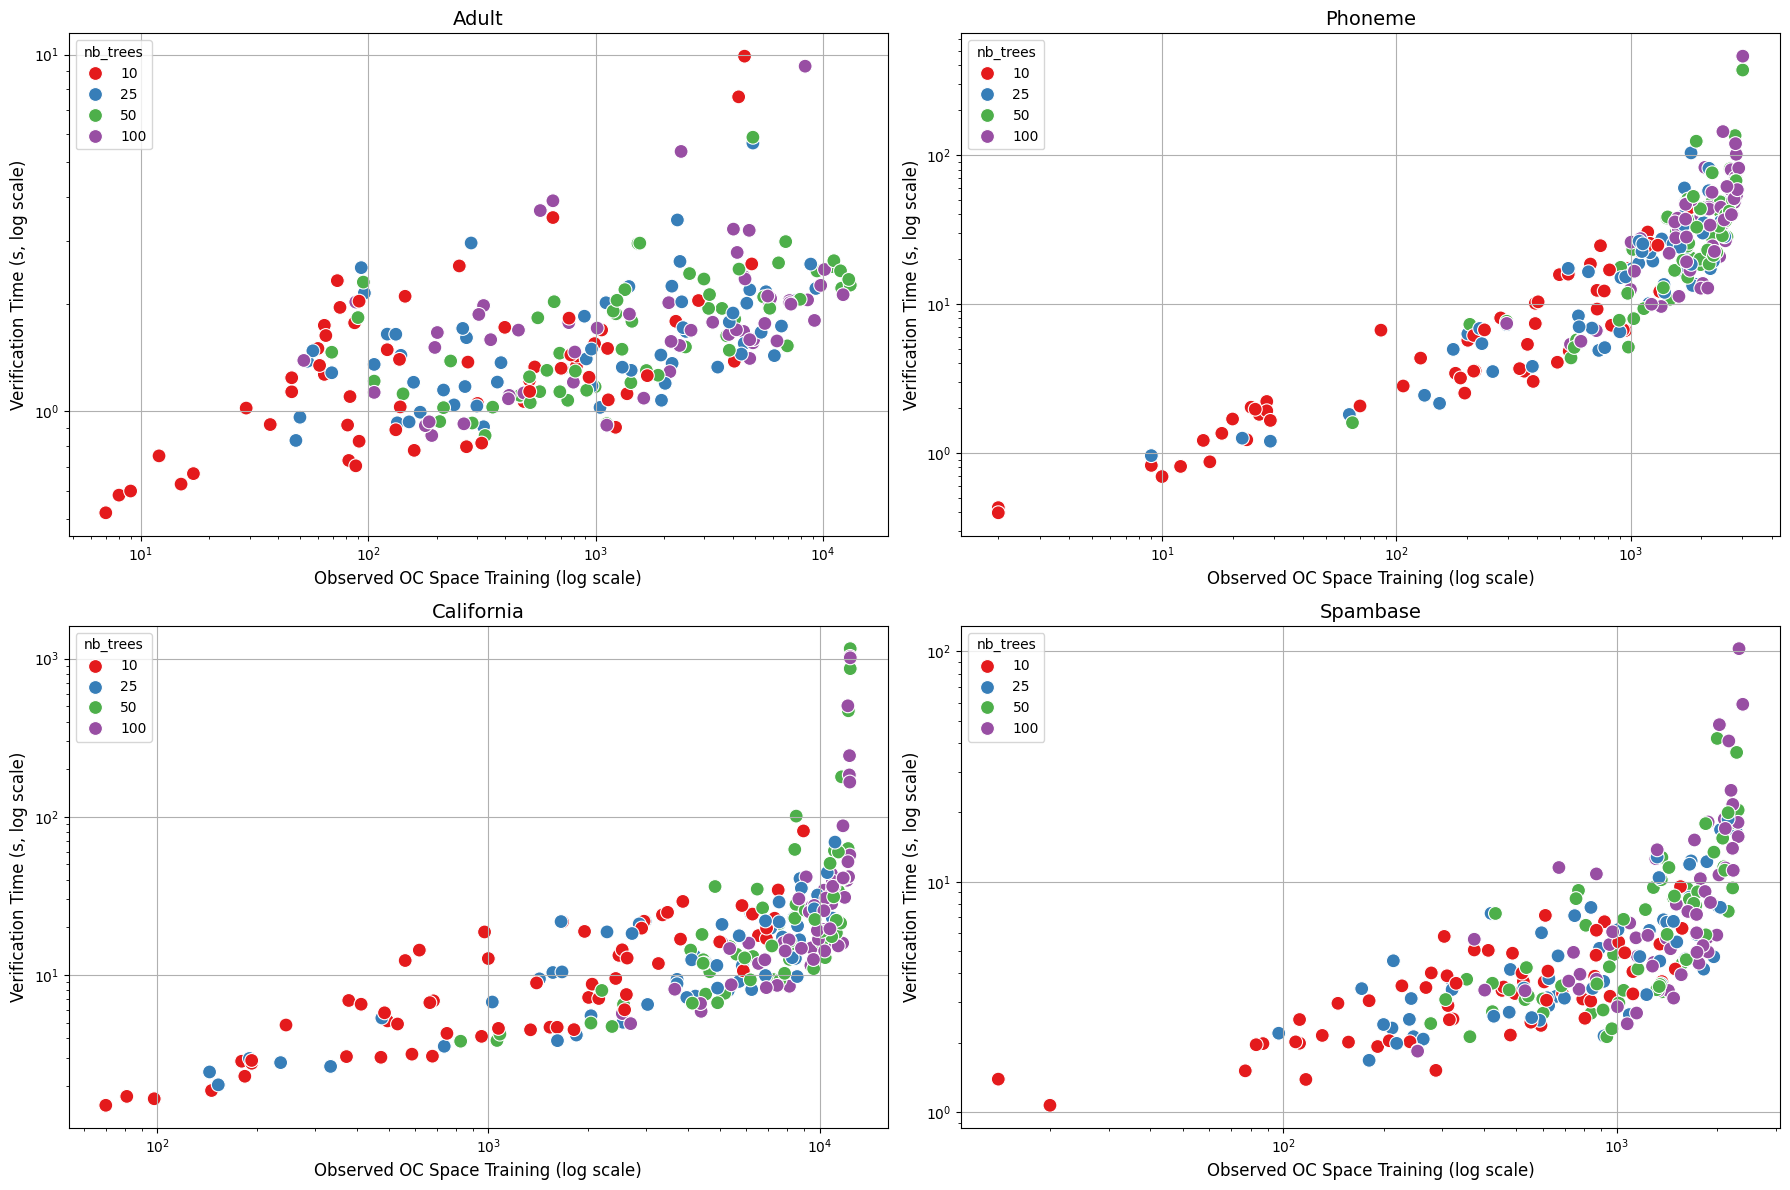

In [ ]:
# Plot observed oc space training vs verification time per dataset
import matplotlib.pyplot as plt

# Get unique datasets
unique_datasets = df['dname'].unique()
n_datasets = len(unique_datasets)

# Create subplots
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()

for i, dataset in enumerate(unique_datasets):
    if i < len(axes):
        dataset_df = df[df['dname'] == dataset]
        
        sns.scatterplot(x='observed_oc_space_training', y='ver_time', hue='nb_trees', data=dataset_df, 
                       s=100, ax=axes[i], palette='Set1')
        axes[i].set_xscale('log')
        axes[i].set_yscale('log')
        axes[i].set_xlabel('Observed OC Space Training (log scale)', fontsize=12)
        axes[i].set_ylabel('Verification Time (s, log scale)', fontsize=12)
        axes[i].set_title(f'{dataset}', fontsize=14)
        axes[i].grid(True)

# Hide unused subplots
for i in range(n_datasets, len(axes)):
    axes[i].axis('off')

plt.tight_layout()
plt.savefig('plots/observed_oc_space_training_vs_ver_time_per_dataset.png', dpi=300)
plt.show()

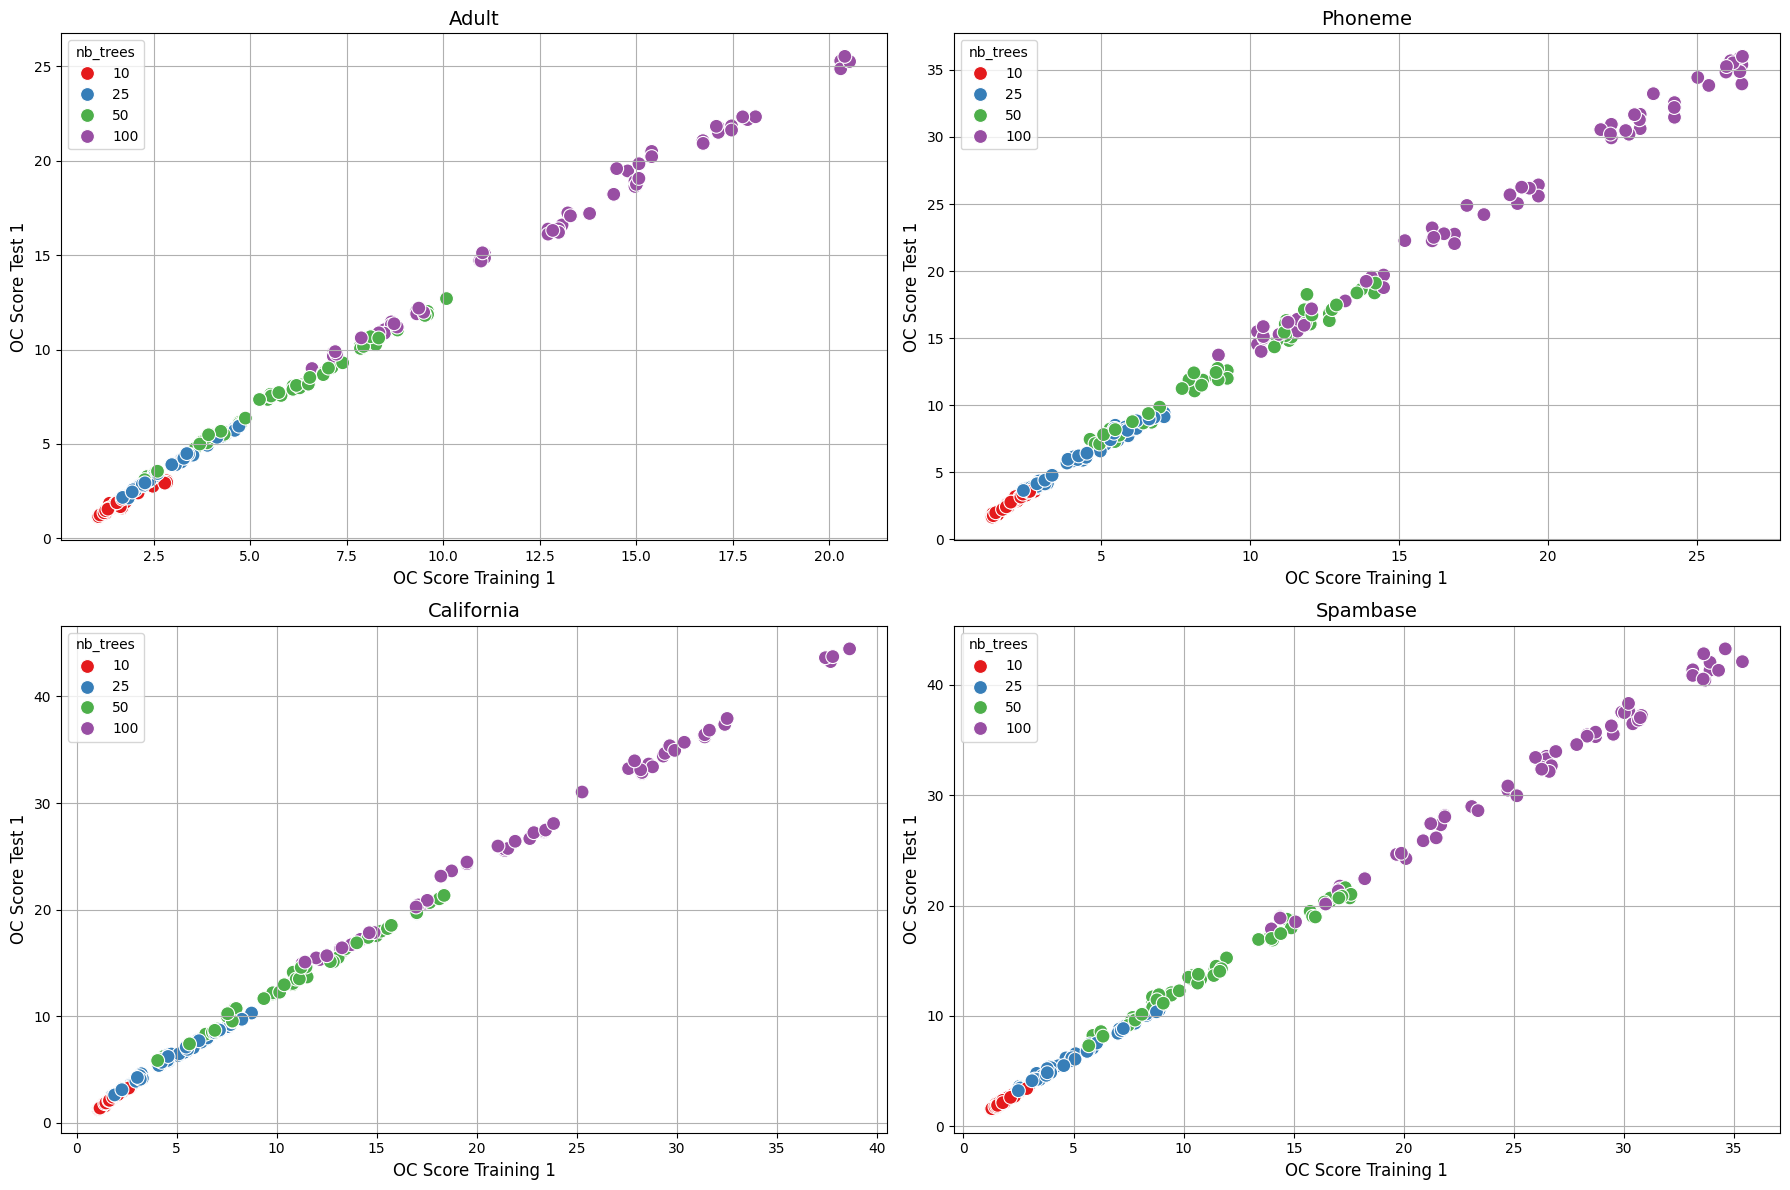

In [ ]:
# Plot oc_score training vs oc_score test per dataset
import matplotlib.pyplot as plt

# Get unique datasets
unique_datasets = df['dname'].unique()
n_datasets = len(unique_datasets)

# Create subplots
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()

for i, dataset in enumerate(unique_datasets):
    if i < len(axes):
        dataset_df = df[df['dname'] == dataset]

        sns.scatterplot(x='oc_score_training_1', y='oc_score_test_1', hue='nb_trees', data=dataset_df,
                       s=100, ax=axes[i], palette='Set1')
        axes[i].set_xlabel('OC Score Training 1', fontsize=12)
        axes[i].set_ylabel('OC Score Test 1', fontsize=12)
        axes[i].set_title(f'{dataset}', fontsize=14)
        axes[i].grid(True)

# Hide unused subplots
for i in range(n_datasets, len(axes)):
    axes[i].axis('off')

plt.tight_layout()
plt.savefig('plots/oc_score_training_vs_oc_score_test_per_dataset.png', dpi=300)
plt.show()


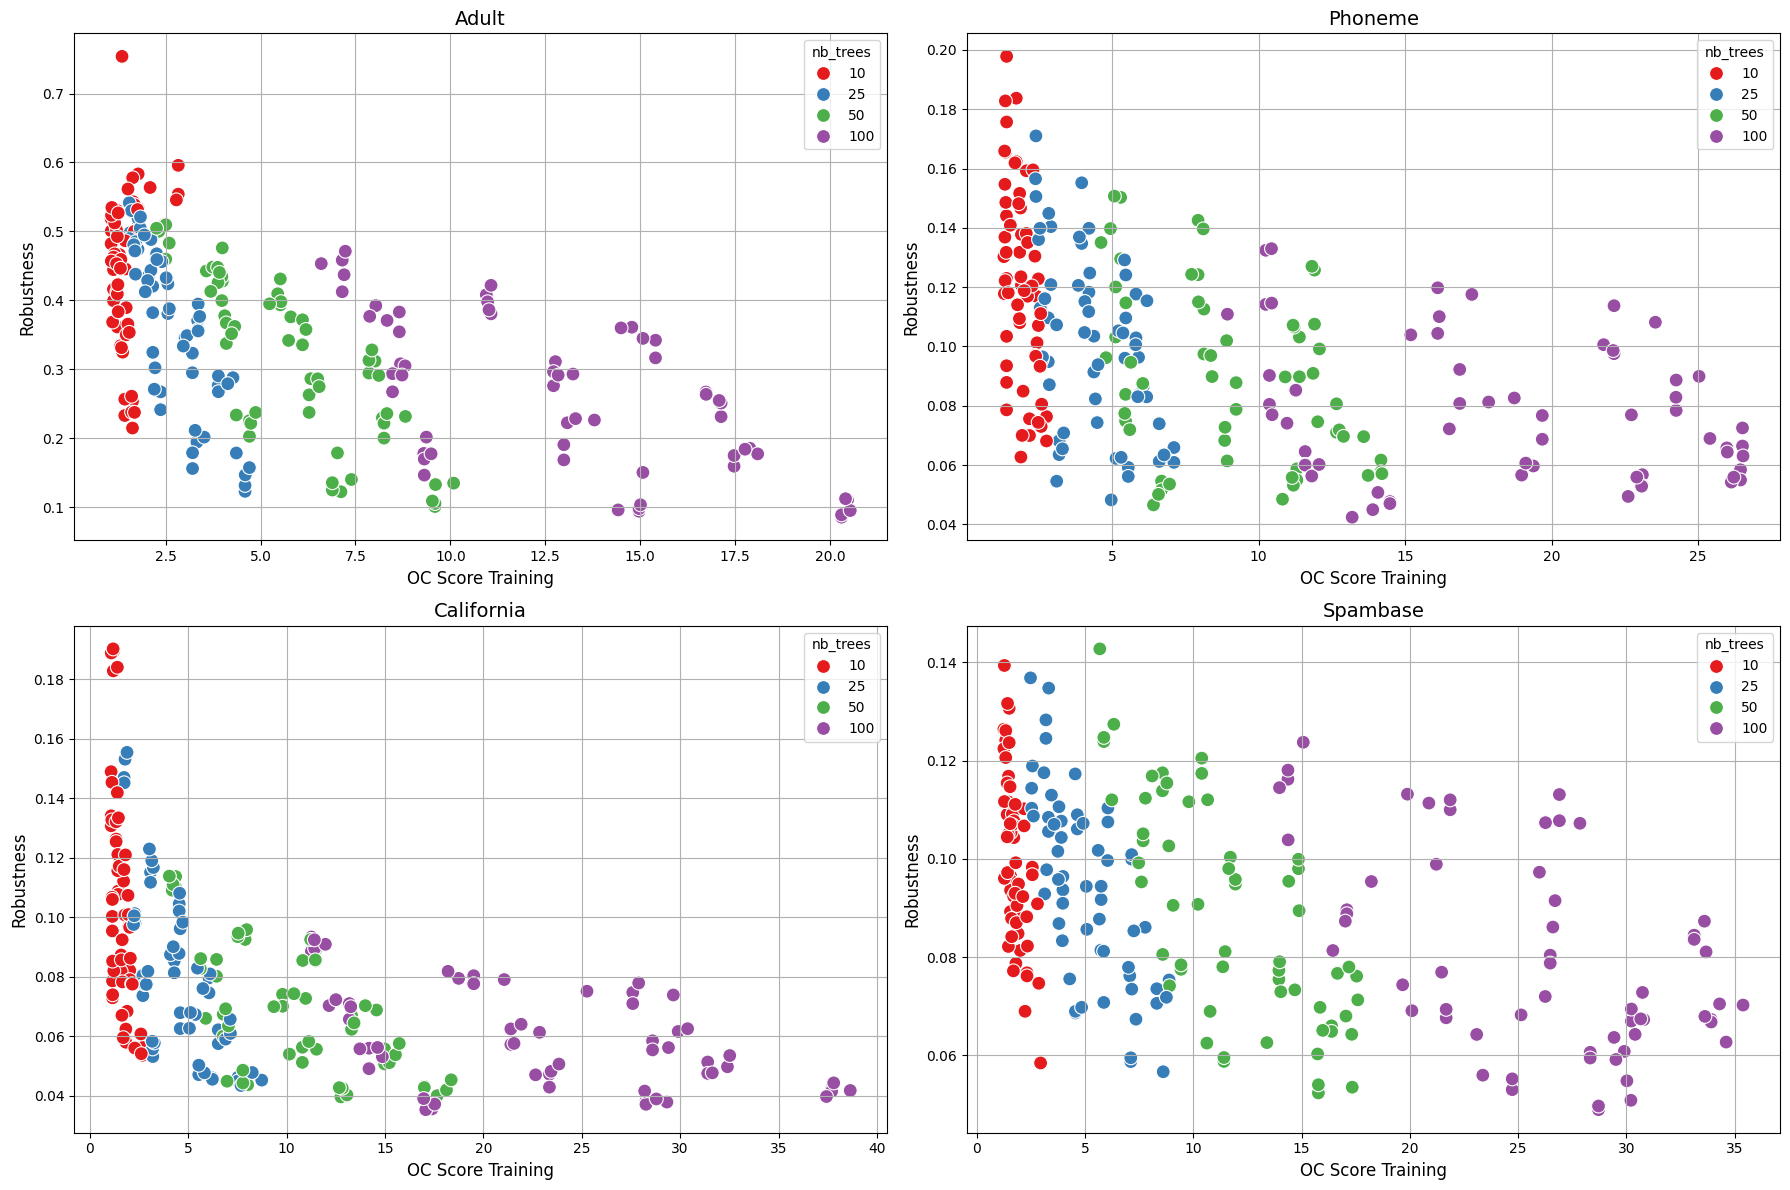

In [ ]:
# Plot oc_score of training vs robustness per dataset
import matplotlib.pyplot as plt

# Get unique datasets
unique_datasets = df['dname'].unique()
n_datasets = len(unique_datasets)

# Create subplots
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()

for i, dataset in enumerate(unique_datasets):
    if i < len(axes):
        dataset_df = df[df['dname'] == dataset]

        sns.scatterplot(x='oc_score_training_1', y='robustness', hue='nb_trees', data=dataset_df,
                       s=100, ax=axes[i], palette='Set1')
        # axes[i].set_xscale('log')
        # axes[i].set_yscale('log')
        axes[i].set_xlabel('OC Score Training', fontsize=12)
        axes[i].set_ylabel('Robustness', fontsize=12)
        axes[i].set_title(f'{dataset}', fontsize=14)
        axes[i].grid(True)

# Hide unused subplots
for i in range(n_datasets, len(axes)):
    axes[i].axis('off')

plt.tight_layout()
plt.savefig('plots/oc_score_training_vs_robustness_per_dataset.png', dpi=300)
plt.show()


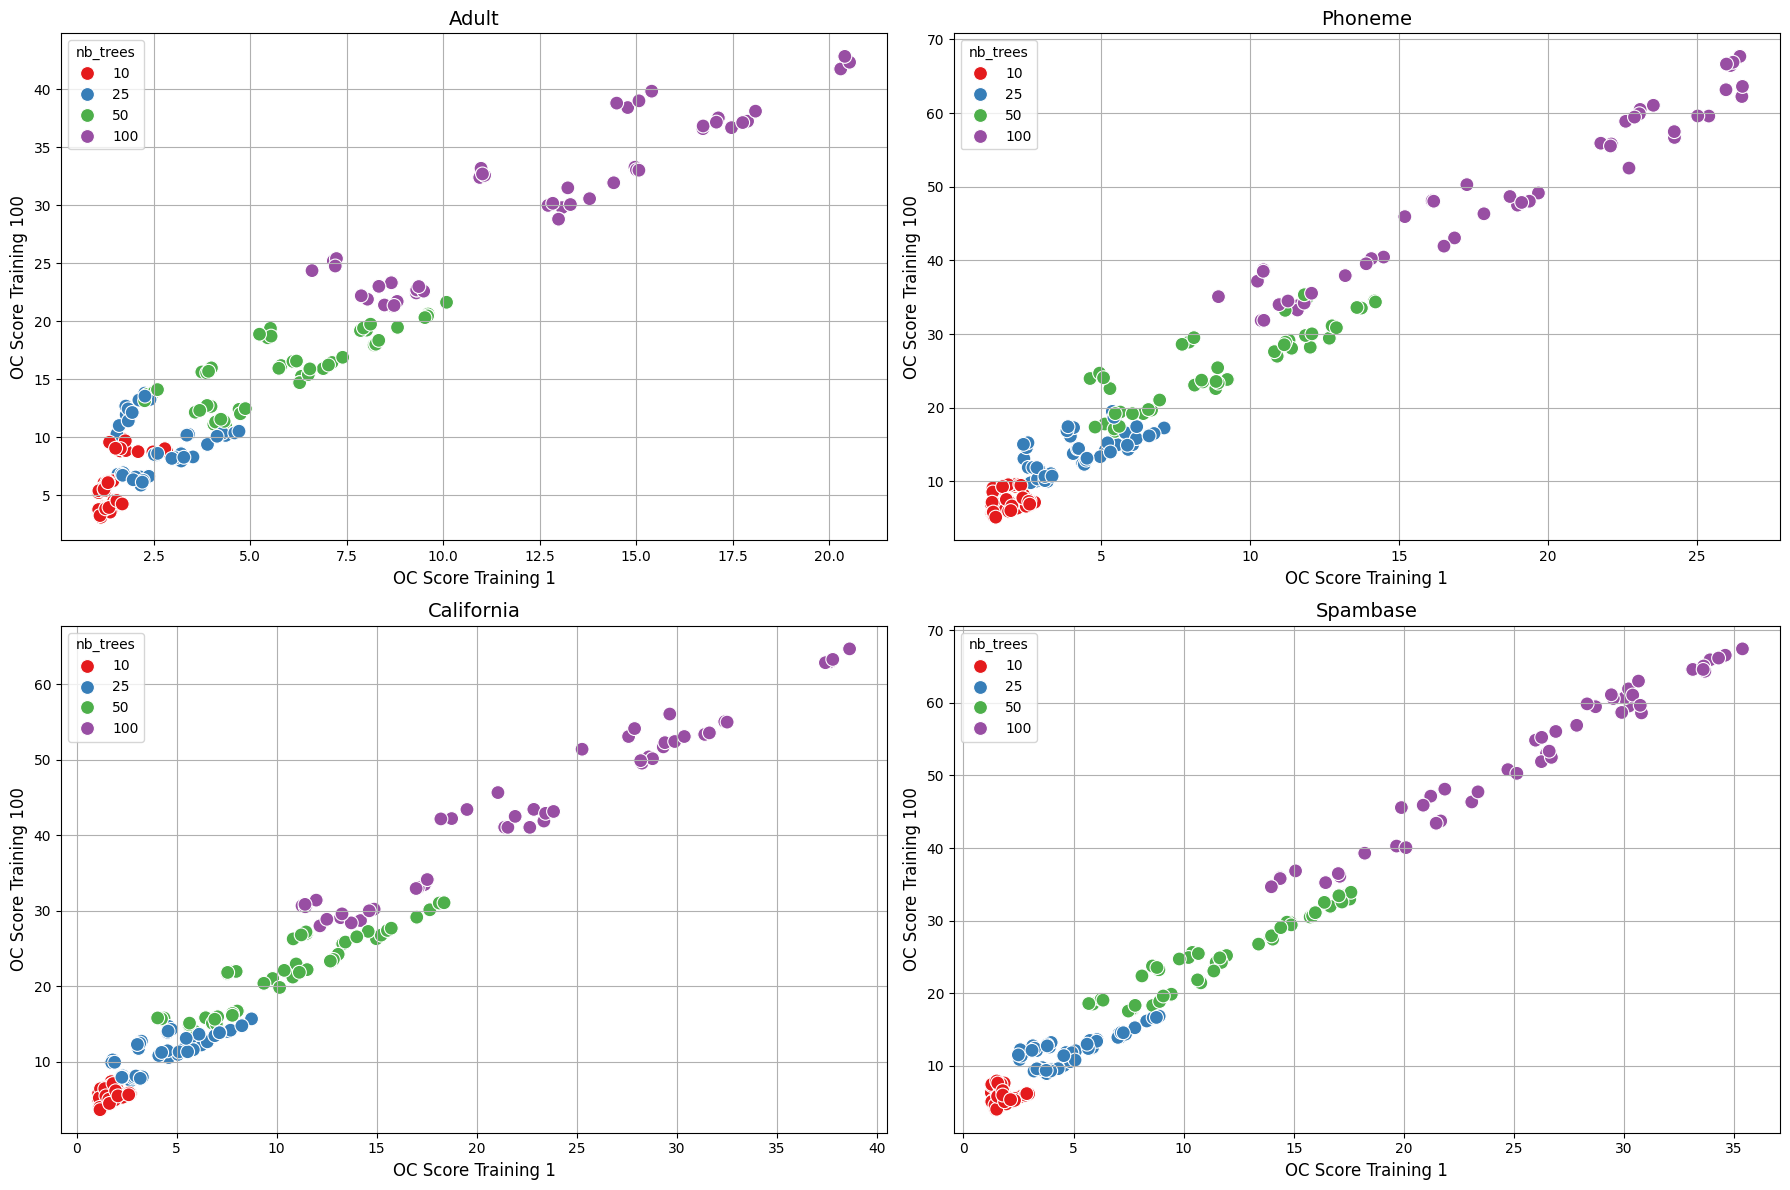

In [ ]:
# Plot oc score training 1 vs oc score training 100 per dataset
import matplotlib.pyplot as plt

# Get unique datasets
unique_datasets = df['dname'].unique()
n_datasets = len(unique_datasets)

# Create subplots
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()

for i, dataset in enumerate(unique_datasets):
    if i < len(axes):
        dataset_df = df[df['dname'] == dataset]

        sns.scatterplot(x='oc_score_training_1', y='oc_score_training_100', hue='nb_trees', data=dataset_df,
                       s=100, ax=axes[i], palette='Set1')
        axes[i].set_xlabel('OC Score Training 1', fontsize=12)
        axes[i].set_ylabel('OC Score Training 100', fontsize=12)
        axes[i].set_title(f'{dataset}', fontsize=14)
        axes[i].grid(True)

# Hide unused subplots
for i in range(n_datasets, len(axes)):
    axes[i].axis('off')

plt.tight_layout()
plt.savefig('plots/oc_score_training_vs_oc_score_training_100_per_dataset.png', dpi=300)
plt.show()


In [ ]:
# This cell is only used for analysing oc_space vs verification time on the smaller ensembles
import json
results_oc_calcs = {}
datasets = set()
with open('results/xgb_oc_calcs_small.txt', 'r') as file:
    for line in file:
        if not line.startswith('{'):
            continue
        line_dict = json.loads(line.strip())
        key = f"{line_dict['dname']}_{line_dict['params']['n_estimators']}_{line_dict['params']['max_depth']}_{line_dict['params']['learning_rate']}_{line_dict['fold']}"
        results_oc_calcs[key] = line_dict
        datasets.add(line_dict['dname'])

In [ ]:
import pandas as pd

df = []
for d in datasets:
    keys = [k for k in results_oc_calcs.keys() if k.split('_')[0] == d]
    
    for i, k in enumerate(keys):
        # print(results_oc_calcs[k])
        oc_bound_leafs = results_oc_calcs[k]['refinements'][0]['oc_space_bound'][1]
        oc_bound_features = results_oc_calcs[k]['refinements'][0]['oc_space_bound'][0]
        ver_time = results_oc_calcs[k]['refinements'][0]['verification_results']["exact_emp_rob_time"]
        ver_timeout = results_oc_calcs[k]['refinements'][0]['verification_results']["exact_emp_rob_timeout"]
        robustness = results_oc_calcs[k]['refinements'][0]['verification_results']["exact_emp_rob"]

        oc_space = results_oc_calcs[k]['refinements'][0]['oc_space'][0]
        bacc = results_oc_calcs[k]['mtest']

        n_leafs = results_oc_calcs[k]['nleafs']

        df.append([d, oc_bound_leafs, oc_bound_features, ver_time, ver_timeout, robustness, oc_space, bacc, n_leafs])

df = pd.DataFrame(df, columns=['dname', 'oc_bound_leafs', 'oc_bound_features', 'ver_time', 'ver_timeout', 'robustness', 'oc_space', 'bacc', 'n_leafs'])


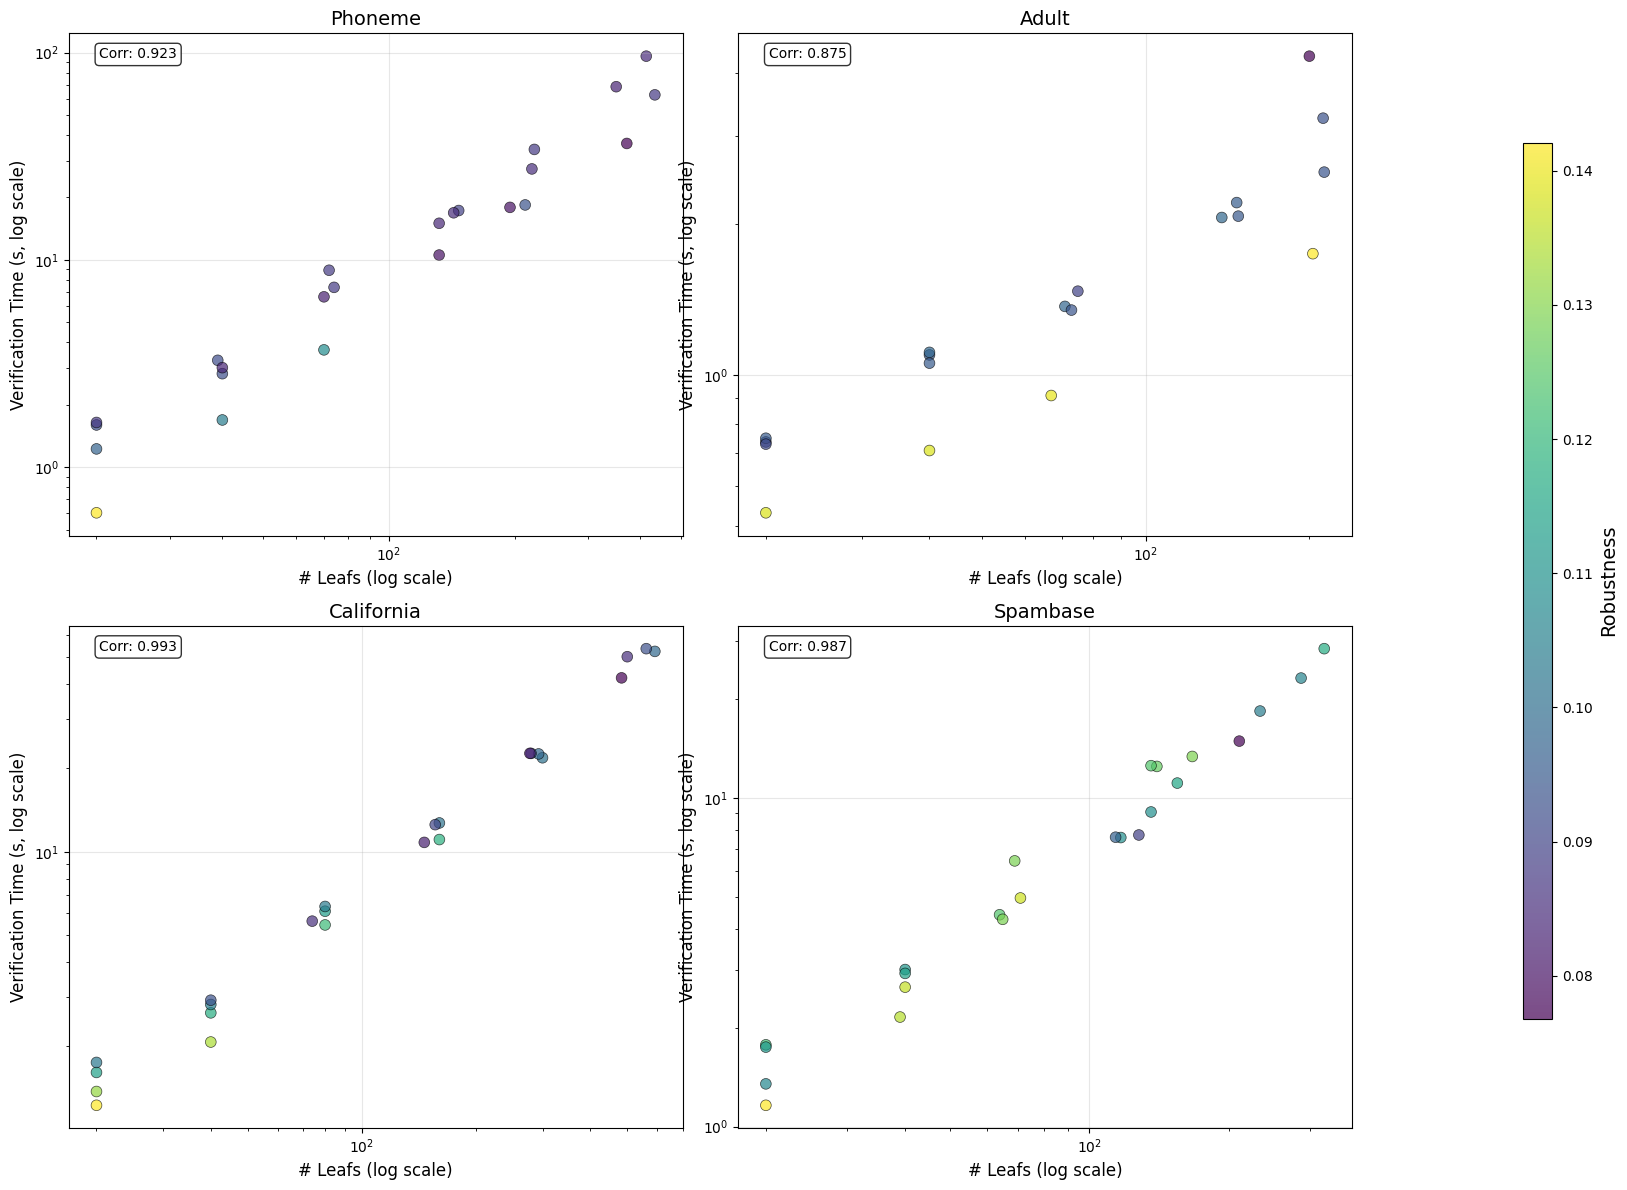


Phoneme:
  Data points: 24
  # Leafs range: 20 to 433
  Verification time range: 0.602s to 96.081s
  Correlation: 0.923

Adult:
  Data points: 19
  # Leafs range: 20 to 213
  Verification time range: 0.531s to 4.321s
  Correlation: 0.875

California:
  Data points: 24
  # Leafs range: 20 to 591
  Verification time range: 1.225s to 53.748s
  Correlation: 0.993

Spambase:
  Data points: 24
  # Leafs range: 20 to 322
  Verification time range: 1.161s to 28.393s
  Correlation: 0.987


In [ ]:
# Plot verification time vs n_leafs per dataset
import matplotlib.pyplot as plt

# Get unique datasets
unique_datasets = df['dname'].unique()
n_datasets = len(unique_datasets)

# Create subplots
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()

for i, dataset in enumerate(unique_datasets):
    if i < len(axes):
        dataset_df = df[df['dname'] == dataset]
        
        # Create scatter plot with color coding by robustness
        scatter = axes[i].scatter(dataset_df['n_leafs'], dataset_df['ver_time'], 
                                 c=dataset_df['robustness'], cmap='viridis', 
                                 alpha=0.7, s=60, edgecolors='black', linewidth=0.5)
        
        # Set log scales
        axes[i].set_xscale('log')
        axes[i].set_yscale('log')
        
        # Labels and title
        axes[i].set_xlabel('# Leafs (log scale)', fontsize=12)
        axes[i].set_ylabel('Verification Time (s, log scale)', fontsize=12)
        axes[i].set_title(f'{dataset}', fontsize=14)
        axes[i].grid(True, alpha=0.3)
        
        # Add correlation text
        correlation = dataset_df['n_leafs'].corr(dataset_df['ver_time'])
        axes[i].text(0.05, 0.95, f'Corr: {correlation:.3f}', 
                    transform=axes[i].transAxes, fontsize=10,
                    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Hide unused subplots
for i in range(n_datasets, len(axes)):
    axes[i].axis('off')

# Add a colorbar for the entire figure
plt.tight_layout()
# Create colorbar on the right side of the figure
cbar = fig.colorbar(scatter, ax=axes, shrink=0.8, aspect=30, pad=0.1)
cbar.set_label('Robustness', fontsize=14)

plt.savefig('plots/ver_time_vs_n_leafs_per_dataset.png', dpi=300, bbox_inches='tight')
plt.show()

# Print summary statistics per dataset
for dataset in unique_datasets:
    dataset_df = df[df['dname'] == dataset]
    correlation = dataset_df['n_leafs'].corr(dataset_df['ver_time'])
    print(f"\n{dataset}:")
    print(f"  Data points: {len(dataset_df)}")
    print(f"  # Leafs range: {dataset_df['n_leafs'].min():,} to {dataset_df['n_leafs'].max():,}")
    print(f"  Verification time range: {dataset_df['ver_time'].min():.3f}s to {dataset_df['ver_time'].max():.3f}s")
    print(f"  Correlation: {correlation:.3f}")

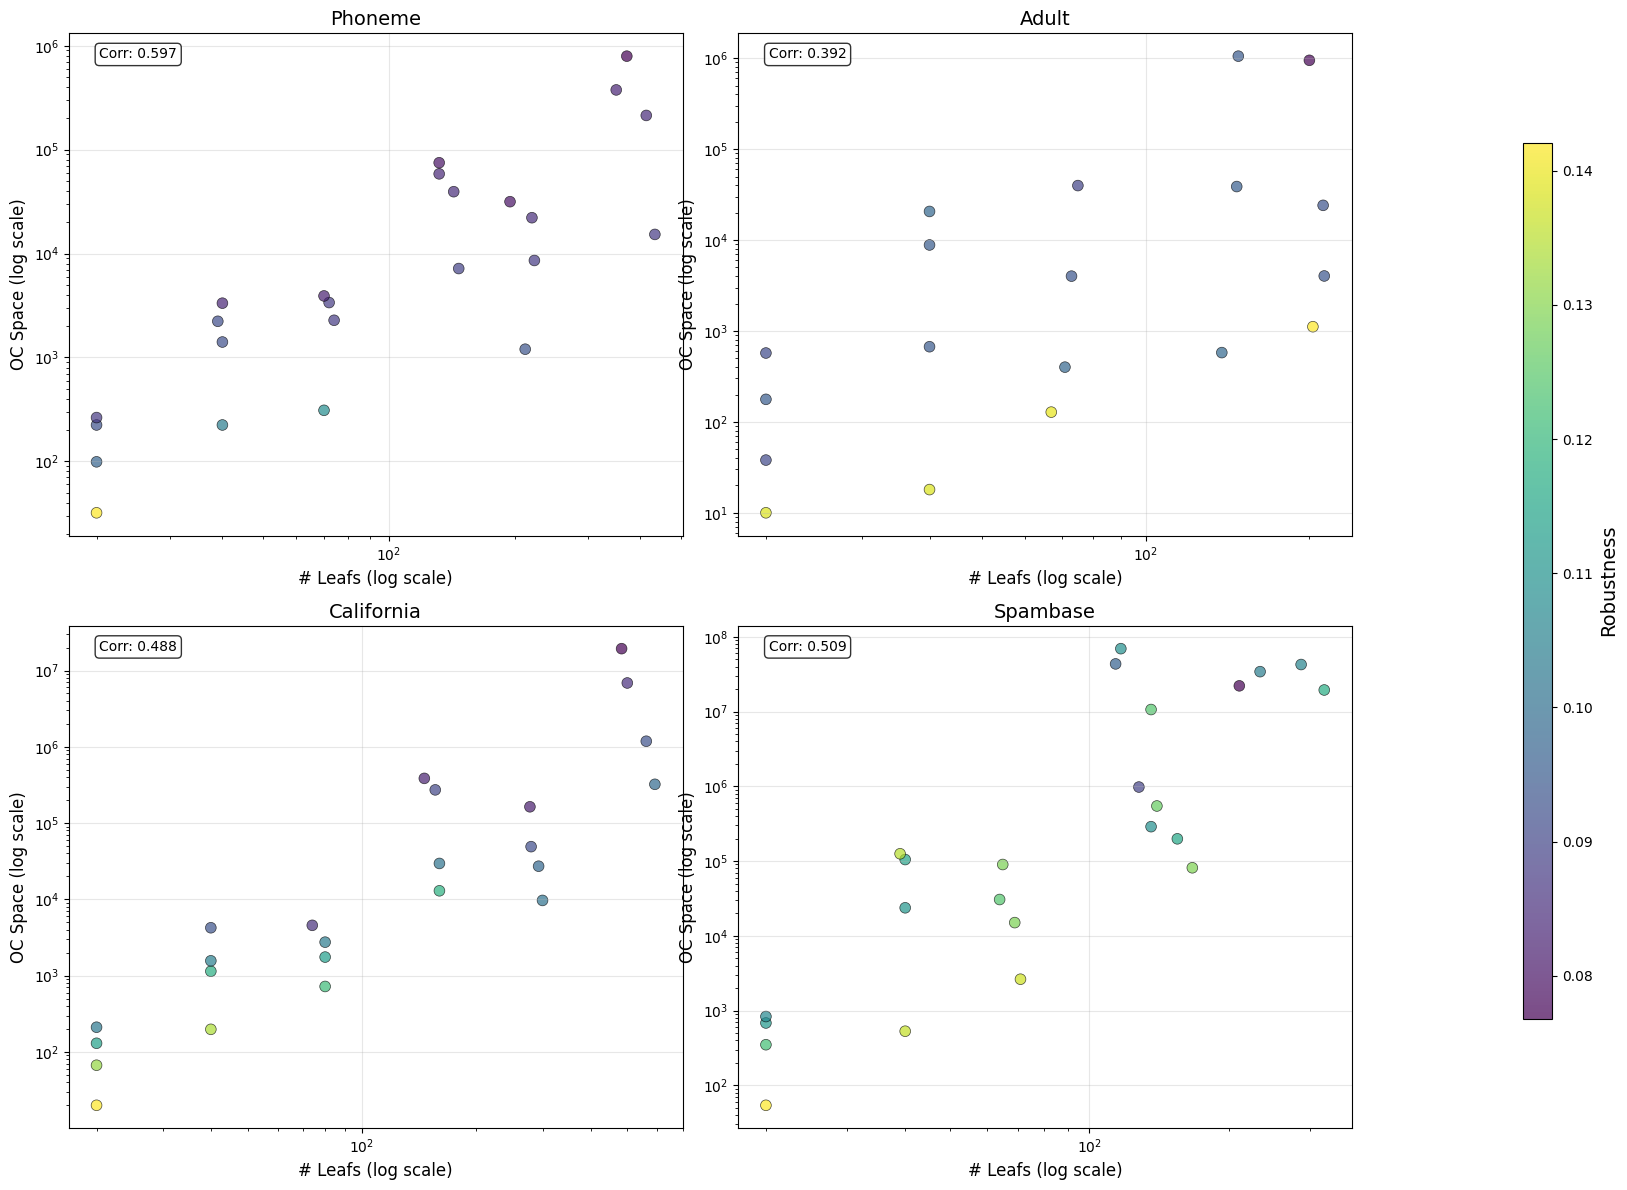


Phoneme:
  Data points: 24
  # Leafs range: 20 to 433
  OC Space range: 32 to 793,605
  Correlation: 0.597

Adult:
  Data points: 19
  # Leafs range: 20 to 213
  OC Space range: 10 to 1,053,406
  Correlation: 0.392

California:
  Data points: 24
  # Leafs range: 20 to 591
  OC Space range: 20 to 19,331,840
  Correlation: 0.488

Spambase:
  Data points: 24
  # Leafs range: 20 to 322
  OC Space range: 54 to 69,511,604
  Correlation: 0.509


In [ ]:
# Plot verification time vs n_leafs per dataset
import matplotlib.pyplot as plt

# Get unique datasets
unique_datasets = df['dname'].unique()
n_datasets = len(unique_datasets)

# Create subplots
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()

for i, dataset in enumerate(unique_datasets):
    if i < len(axes):
        dataset_df = df[df['dname'] == dataset]
        
        # Create scatter plot with color coding by robustness
        scatter = axes[i].scatter(dataset_df['n_leafs'], dataset_df['oc_space'], 
                                 c=dataset_df['robustness'], cmap='viridis', 
                                 alpha=0.7, s=60, edgecolors='black', linewidth=0.5)
        
        # Set log scales
        axes[i].set_xscale('log')
        axes[i].set_yscale('log')
        
        # Labels and title
        axes[i].set_xlabel('# Leafs (log scale)', fontsize=12)
        axes[i].set_ylabel('OC Space (log scale)', fontsize=12)
        axes[i].set_title(f'{dataset}', fontsize=14)
        axes[i].grid(True, alpha=0.3)
        
        # Add correlation text
        correlation = dataset_df['n_leafs'].corr(dataset_df['oc_space'])
        axes[i].text(0.05, 0.95, f'Corr: {correlation:.3f}', 
                    transform=axes[i].transAxes, fontsize=10,
                    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Hide unused subplots
for i in range(n_datasets, len(axes)):
    axes[i].axis('off')

# Add a colorbar for the entire figure
plt.tight_layout()
# Create colorbar on the right side of the figure
cbar = fig.colorbar(scatter, ax=axes, shrink=0.8, aspect=30, pad=0.1)
cbar.set_label('Robustness', fontsize=14)

plt.savefig('plots/oc_space_vs_n_leafs_per_dataset.png', dpi=300, bbox_inches='tight')
plt.show()

# Print summary statistics per dataset
for dataset in unique_datasets:
    dataset_df = df[df['dname'] == dataset]
    correlation = dataset_df['n_leafs'].corr(dataset_df['oc_space'])
    print(f"\n{dataset}:")
    print(f"  Data points: {len(dataset_df)}")
    print(f"  # Leafs range: {dataset_df['n_leafs'].min():,} to {dataset_df['n_leafs'].max():,}")
    print(f"  OC Space range: {dataset_df['oc_space'].min():,} to {dataset_df['oc_space'].max():,}")
    print(f"  Correlation: {correlation:.3f}")

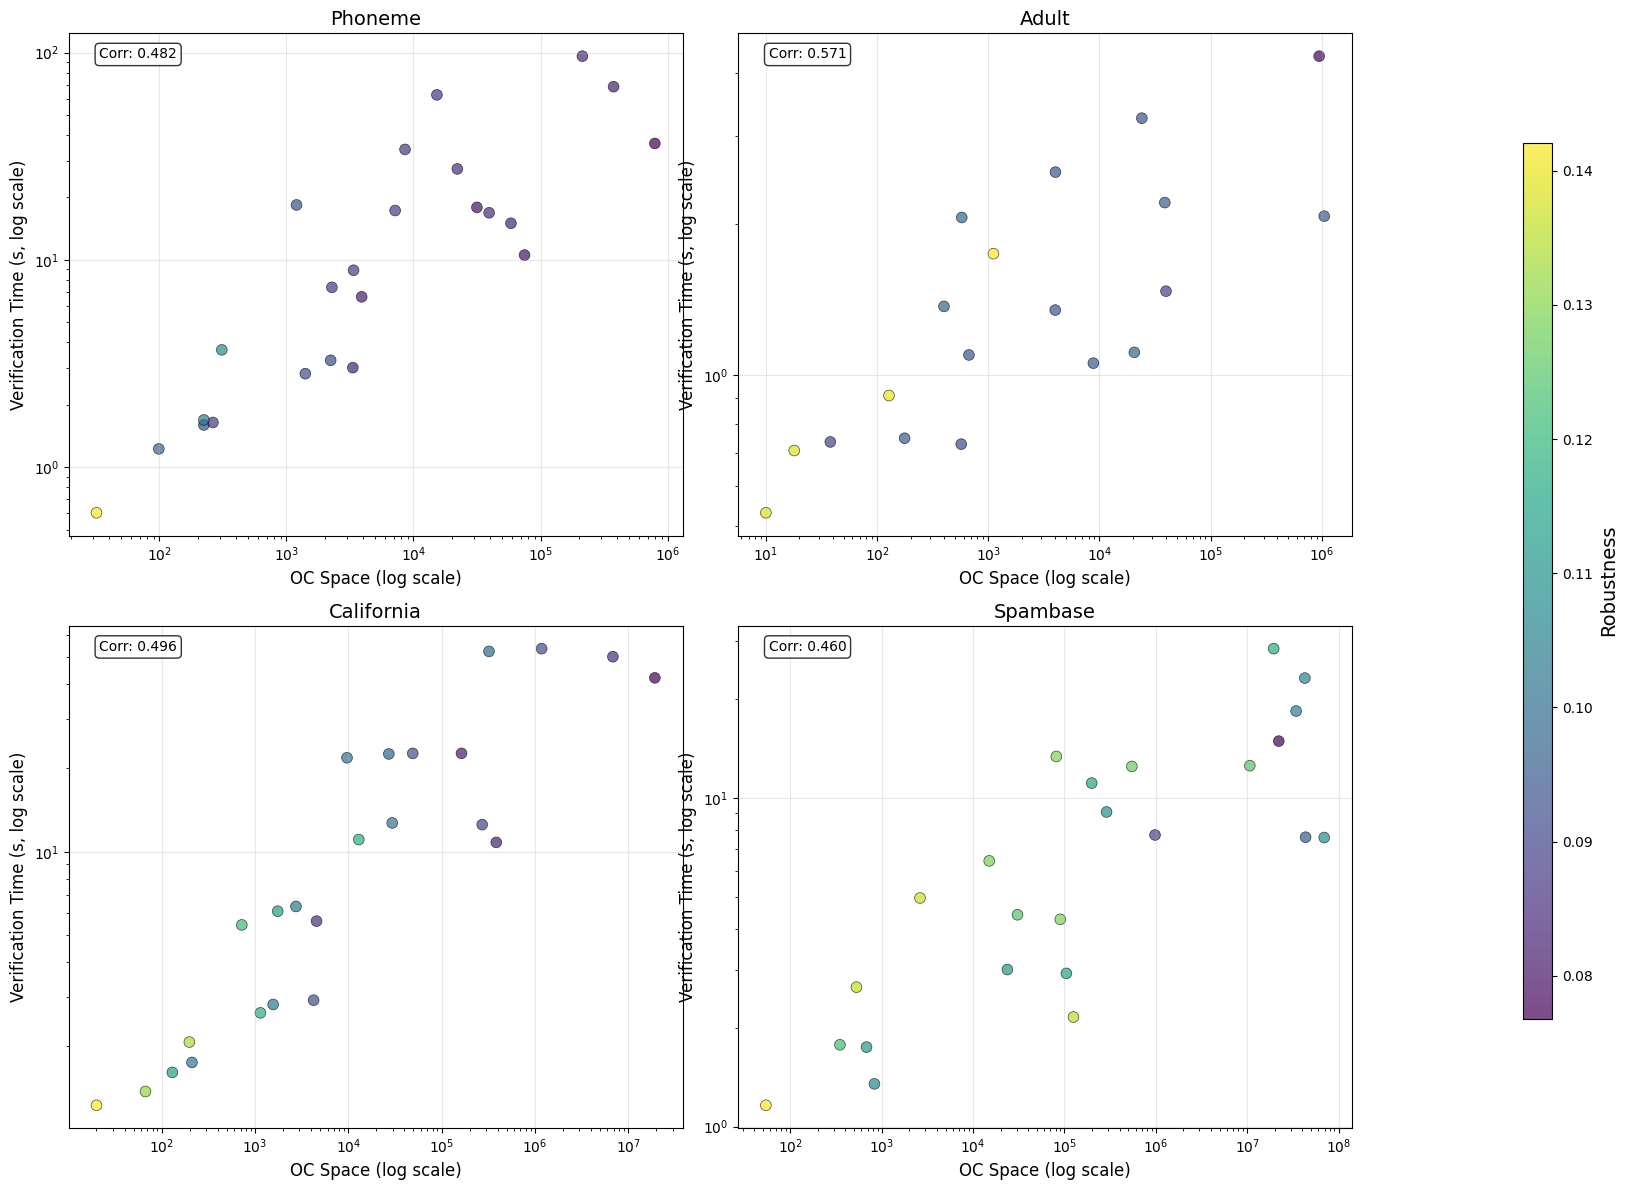


Phoneme:
  Data points: 24
  OC Space range: 32 to 793,605
  Verification time range: 0.602s to 96.081s
  Correlation: 0.482

Adult:
  Data points: 19
  OC Space range: 10 to 1,053,406
  Verification time range: 0.531s to 4.321s
  Correlation: 0.571

California:
  Data points: 24
  OC Space range: 20 to 19,331,840
  Verification time range: 1.225s to 53.748s
  Correlation: 0.496

Spambase:
  Data points: 24
  OC Space range: 54 to 69,511,604
  Verification time range: 1.161s to 28.393s
  Correlation: 0.460


In [ ]:
# Plot verification time vs n_leafs per dataset
import matplotlib.pyplot as plt

# Get unique datasets
unique_datasets = df['dname'].unique()
n_datasets = len(unique_datasets)

# Create subplots
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()

for i, dataset in enumerate(unique_datasets):
    if i < len(axes):
        dataset_df = df[df['dname'] == dataset]
        
        # Create scatter plot with color coding by robustness
        scatter = axes[i].scatter(dataset_df['oc_space'], dataset_df['ver_time'], 
                                 c=dataset_df['robustness'], cmap='viridis', 
                                 alpha=0.7, s=60, edgecolors='black', linewidth=0.5)
        
        # Set log scales
        axes[i].set_xscale('log')
        axes[i].set_yscale('log')
        
        # Labels and title
        axes[i].set_xlabel('OC Space (log scale)', fontsize=12)
        axes[i].set_ylabel('Verification Time (s, log scale)', fontsize=12)
        axes[i].set_title(f'{dataset}', fontsize=14)
        axes[i].grid(True, alpha=0.3)
        
        # Add correlation text
        correlation = dataset_df['oc_space'].corr(dataset_df['ver_time'])
        axes[i].text(0.05, 0.95, f'Corr: {correlation:.3f}', 
                    transform=axes[i].transAxes, fontsize=10,
                    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Hide unused subplots
for i in range(n_datasets, len(axes)):
    axes[i].axis('off')

# Add a colorbar for the entire figure
plt.tight_layout()
# Create colorbar on the right side of the figure
cbar = fig.colorbar(scatter, ax=axes, shrink=0.8, aspect=30, pad=0.1)
cbar.set_label('Robustness', fontsize=14)

plt.savefig('plots/ver_time_vs_oc_space_per_dataset.png', dpi=300, bbox_inches='tight')
plt.show()

# Print summary statistics per dataset
for dataset in unique_datasets:
    dataset_df = df[df['dname'] == dataset]
    correlation = dataset_df['oc_space'].corr(dataset_df['ver_time'])
    print(f"\n{dataset}:")
    print(f"  Data points: {len(dataset_df)}")
    print(f"  OC Space range: {dataset_df['oc_space'].min():,} to {dataset_df['oc_space'].max():,}")
    print(f"  Verification time range: {dataset_df['ver_time'].min():.3f}s to {dataset_df['ver_time'].max():.3f}s")
    print(f"  Correlation: {correlation:.3f}")

In [ ]:
# collecting the results
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

df = []
for d in datasets:
    keys = [k for k in results_oc_calcs.keys() if k.split('_')[0] == d]
    
    for i, k in enumerate(keys):
        # print(k)
        # print(results_oc_calcs[k])
        oc_bound_leafs = results_oc_calcs[k]['bound_oc_space'][1]
        oc_bound_features = results_oc_calcs[k]['bound_oc_space'][0]
        ver_time = results_oc_calcs[k]['verifications']["exact_emp_rob_time"]
        ver_timeout = results_oc_calcs[k]['verifications']["exact_emp_rob_timeout"]
        robustness = results_oc_calcs[k]['verifications']["exact_emp_rob"]

        nb_trees = results_oc_calcs[k]['params']['n_estimators']
        max_depth = results_oc_calcs[k]['params']['max_depth']
        learning_rate = results_oc_calcs[k]['params']['learning_rate']

        oc_score_training_1 = 1/2 * results_oc_calcs[k]['oc_score_training']['0']['oc_score_k1'] + 1/2 * results_oc_calcs[k]['oc_score_training']['1']['oc_score_k1']
        oc_score_test_1 = 1/2 * results_oc_calcs[k]['oc_score_test']['0']['oc_score_k1'] + 1/2 * results_oc_calcs[k]['oc_score_test']['1']['oc_score_k1']

        oc_score_training_100 = 1/2 * results_oc_calcs[k]['oc_score_training']['0']['oc_score_k100'] + 1/2 * results_oc_calcs[k]['oc_score_training']['1']['oc_score_k100']
        oc_score_test_100 = 1/2 * results_oc_calcs[k]['oc_score_test']['0']['oc_score_k100'] + 1/2 * results_oc_calcs[k]['oc_score_test']['1']['oc_score_k100']

        observed_oc_space_training = results_oc_calcs[k]['observed_oc_space_training']
        observed_oc_space_test = results_oc_calcs[k]['observed_oc_space_test']

        df.append([d, oc_bound_leafs, oc_bound_features, ver_time, ver_timeout, robustness, nb_trees, max_depth, learning_rate, oc_score_training_1, oc_score_test_1, oc_score_training_100, oc_score_test_100, observed_oc_space_training, observed_oc_space_test])

df = pd.DataFrame(df, columns=['dname', 'oc_bound_leafs', 'oc_bound_features', 'ver_time', 'ver_timeout', 'robustness', 'nb_trees', 'max_depth', 'learning_rate', 'oc_score_training_1', 'oc_score_test_1', 'oc_score_training_100', 'oc_score_test_100', 'observed_oc_space_training', 'observed_oc_space_test'])

In [ ]:
import json
results_practical_metrics = {}
datasets = set()
with open('results/xgb_verification_ocs.txt', 'r') as file:
    for line in file:
        if not line.startswith('{'):
            continue
        line_dict = json.loads(line.strip())
        key = f"{line_dict['dname']}_{line_dict['params']['n_estimators']}_{line_dict['params']['max_depth']}_{line_dict['params']['learning_rate']}_{line_dict['fold']}"
        results_practical_metrics[key] = line_dict
        datasets.add(line_dict['dname'])

In [ ]:
# Print the number of times that the oc space count search runs out of resources per dataset and method
# This checks the ['oc_space'][2] value which indicates if the search ran out of resources

timeout_counts_by_method = {}

for dataset in sorted(datasets):
    timeout_counts_by_method[dataset] = {}
    
    for key, data in results_practical_metrics.items():
        if key.split('_')[0] == dataset:
            for refinement in data['refinements']:
                method = refinement['penalty']
                if method not in timeout_counts_by_method[dataset]:
                    timeout_counts_by_method[dataset][method] = {'timeouts': 0, 'total': 0}
                
                if 'oc_space' in refinement and len(refinement['oc_space']) > 2:
                    timeout_counts_by_method[dataset][method]['total'] += 1
                    if refinement['oc_space'][2] == True:  # True indicates timeout/out of resources
                        timeout_counts_by_method[dataset][method]['timeouts'] += 1

# Get all methods
all_methods = set()
for dataset_data in timeout_counts_by_method.values():
    all_methods.update(dataset_data.keys())
all_methods = sorted(all_methods)

# Print table with methods as columns
header = f"{'Dataset':<20}"
for method in all_methods:
    header += f"{method:>12}"
print(header)
print("-" * (20 + 12 * len(all_methods)))

for dataset in sorted(datasets):
    row = f"{dataset:<20}"
    for method in all_methods:
        if method in timeout_counts_by_method[dataset]:
            timeout_count = timeout_counts_by_method[dataset][method]['timeouts']
            total_count = timeout_counts_by_method[dataset][method]['total']
            percentage = (timeout_count / total_count * 100) if total_count > 0 else 0
            row += f"{timeout_count}/{total_count} ({percentage:.0f}%)".rjust(12)
        else:
            row += f"{'N/A':>12}"
    print(row)

# Print overall statistics
print("-" * (20 + 12 * len(all_methods)))
row = f"{'Overall':<20}"
method_totals = {}
for dataset_data in timeout_counts_by_method.values():
    for method, counts in dataset_data.items():
        if method not in method_totals:
            method_totals[method] = {'timeouts': 0, 'total': 0}
        method_totals[method]['timeouts'] += counts['timeouts']
        method_totals[method]['total'] += counts['total']

for method in all_methods:
    if method in method_totals:
        timeout_count = method_totals[method]['timeouts']
        total_count = method_totals[method]['total']
        percentage = (timeout_count / total_count * 100) if total_count > 0 else 0
        row += f"{timeout_count}/{total_count} ({percentage:.0f}%)".rjust(12)
    else:
        row += f"{'N/A':>12}"
print(row)

Dataset                 lop-oc-1   lop-oc-10  lop-oc-100         xgb
--------------------------------------------------------------------
Adult                  0/47 (0%)   0/47 (0%)   0/47 (0%) 26/47 (55%)
California            7/59 (12%)   5/59 (8%)   5/59 (8%) 39/59 (66%)
CompasTwoYears         0/60 (0%)   0/60 (0%)   0/60 (0%)   0/60 (0%)
Credit                 0/60 (0%)   0/60 (0%)   0/60 (0%) 40/60 (67%)
DryBean[6vRest]        4/60 (7%)  7/60 (12%) 10/60 (17%) 47/60 (78%)
Electricity            0/51 (0%)   0/51 (0%)   0/51 (0%) 30/51 (59%)
Ijcnn1                 1/30 (3%)   1/30 (3%)   1/30 (3%) 20/30 (67%)
Jannis                5/24 (21%)  5/24 (21%)  5/24 (21%) 19/24 (79%)
MiniBooNE             5/25 (20%)  4/25 (16%)  4/25 (16%) 20/25 (80%)
Mnist[2v4]            8/60 (13%)  9/60 (15%)  9/60 (15%) 53/60 (88%)
Phoneme                1/60 (2%)   1/60 (2%)   1/60 (2%) 26/60 (43%)
Spambase              9/60 (15%) 11/60 (18%) 11/60 (18%) 53/60 (88%)
Vehicle                5/60 (8%)  

In [ ]:
methods = ['lop', 'lop-oc-1', 'lop-oc-10', 'lop-oc-100']

In [ ]:
import numpy as np
import pandas as pd

# Print the oc_space comparison between XGBoost and compressed models per dataset
# Define the possible values for n_estimators, max_depth, and learning_rate
n_estimators_values = [10, 25, 50, 100]
max_depth_values = [4, 6, 8]
learning_rate_values = [0.1]

# Initialize a dictionary to store reduction factors for each method per dataset
reduction_per_dataset = {}

for dataset in datasets:
    reduction_per_method = {method: [] for method in methods}
    
    for n_estimators in n_estimators_values:
        for max_depth in max_depth_values:
            for learning_rate in learning_rate_values:
                # Filter keys for the current combination and dataset
                keys = [
                    k for k in results_practical_metrics.keys()
                    if k.split('_')[0] == dataset and
                       k.split('_')[1] == str(n_estimators) and
                       k.split('_')[2] == str(max_depth) and
                       k.split('_')[3] == str(learning_rate)
                ]
                
                # Collect oc_space reduction factors for each method
                for key in keys:
                    setting_data = results_practical_metrics[key]
                    xgb_oc_space = setting_data['refinements'][0]['oc_space'][0]  # XGBoost oc_space
                    
                    # Compare each refinement method to XGBoost
                    for refinement in setting_data['refinements']:
                        method = refinement['penalty']
                        if method in reduction_per_method:
                            compressed_oc_space = refinement['oc_space'][0]
                            reduction_factor = xgb_oc_space / compressed_oc_space if compressed_oc_space > 0 else 0
                            if reduction_factor >= 1:
                                reduction_per_method[method].append(reduction_factor) 
    
    reduction_per_dataset[dataset] = reduction_per_method

# Create summary table with mean values
summary_data = []
for dataset in sorted(datasets):
    row = {'Dataset': dataset}
    for method in methods:
        reductions = reduction_per_dataset[dataset][method]
        if reductions:
            mean_reduction = np.mean(reductions)
            row[method] = f"{mean_reduction:.2f}"
        else:
            row[method] = "N/A"
    summary_data.append(row)

# Add overall row
overall_row = {'Dataset': 'Overall'}
for method in methods:
    all_reductions = []
    for dataset_data in reduction_per_dataset.values():
        all_reductions.extend(dataset_data[method])
    if all_reductions:
        overall_mean = np.mean(all_reductions)
        overall_row[method] = f"{overall_mean:.2f}"
    else:
        overall_row[method] = "N/A"
summary_data.append(overall_row)

# Create and display DataFrame
df_summary = pd.DataFrame(summary_data)
print(df_summary.to_string(index=False))


        Dataset lop lop-oc-1 lop-oc-10 lop-oc-100
          Adult N/A 10065.38  11391.20    7585.24
     California N/A   800.78    660.78     576.54
 CompasTwoYears N/A  2179.19   1263.02     856.80
         Credit N/A  7016.91   3556.60    3957.77
DryBean[6vRest] N/A 55611.00  54630.09    7884.49
    Electricity N/A   455.25    335.52     307.57
         Ijcnn1 N/A 37258.56  31159.07   16988.29
         Jannis N/A   444.08    367.83     288.24
      MiniBooNE N/A  1541.21   1229.52    1022.50
     Mnist[2v4] N/A 12935.40  11089.90    5004.37
        Phoneme N/A  1270.39    778.73     768.50
       Spambase N/A 10483.09   9190.48    3389.49
        Vehicle N/A  7171.92   5790.22    6927.09
   Volkert[2v7] N/A  5717.02   5213.93    3292.19
        Overall N/A 11130.26   9700.86    4015.41


In [ ]:
import numpy as np

# Print the oc_space comparison between XGBoost and compressed models per dataset
# Define the possible values for n_estimators, max_depth, and learning_rate
n_estimators_values = [10, 25, 50, 100]
max_depth_values = [4, 6, 8]
learning_rate_values = [0.1]

# Initialize a dictionary to store reduction factors for each method per dataset
reduction_per_dataset = {}

for dataset in datasets:
    reduction_per_method = {method: [] for method in methods}
    
    for n_estimators in n_estimators_values:
        for max_depth in max_depth_values:
            for learning_rate in learning_rate_values:
                # Filter keys for the current combination and dataset
                keys = [
                    k for k in results_practical_metrics.keys()
                    if k.split('_')[0] == dataset and
                       k.split('_')[1] == str(n_estimators) and
                       k.split('_')[2] == str(max_depth) and
                       k.split('_')[3] == str(learning_rate)
                ]
                
                # Collect oc_space reduction factors for each method
                for key in keys:
                    setting_data = results_practical_metrics[key]
                    xgb_oc_space = setting_data['refinements'][0]['observed_oc_space']  # XGBoost oc_space
                    
                    # Compare each refinement method to XGBoost
                    for refinement in setting_data['refinements']:
                        method = refinement['penalty']
                        if method in reduction_per_method:
                            compressed_oc_space = refinement['observed_oc_space']
                            reduction_factor = xgb_oc_space / compressed_oc_space
                            reduction_per_method[method].append(reduction_factor)
    
    reduction_per_dataset[dataset] = reduction_per_method

# Create summary table with mean values only
summary_data = []
for dataset in sorted(datasets):
    row = {'Dataset': dataset}
    for method in methods:
        reductions = reduction_per_dataset[dataset][method]
        if reductions:
            mean_reduction = np.mean(reductions)
            row[method] = f"{mean_reduction:.2f}"
        else:
            row[method] = "N/A"
    summary_data.append(row)

# Add overall row
overall_row = {'Dataset': 'Overall'}
for method in methods:
    all_reductions = []
    for dataset_data in reduction_per_dataset.values():
        all_reductions.extend(dataset_data[method])
    if all_reductions:
        overall_mean = np.mean(all_reductions)
        overall_row[method] = f"{overall_mean:.2f}"
    else:
        overall_row[method] = "N/A"
summary_data.append(overall_row)

# Create and display DataFrame
df_summary = pd.DataFrame(summary_data)
print(df_summary.to_string(index=False))


        Dataset lop lop-oc-1 lop-oc-10 lop-oc-100
          Adult N/A    27.14     25.65      19.04
     California N/A     8.11      6.74       6.36
 CompasTwoYears N/A    98.83     51.37      38.14
         Credit N/A    37.28     29.08      24.47
DryBean[6vRest] N/A    56.27     50.05      14.11
    Electricity N/A     9.23      6.51       5.54
         Ijcnn1 N/A   147.85     93.05      33.43
         Jannis N/A     7.12      6.19       6.11
      MiniBooNE N/A     6.55      5.45       5.30
     Mnist[2v4] N/A     9.12      8.40       6.80
        Phoneme N/A    18.73     10.80       6.49
       Spambase N/A     4.70      4.01       3.87
        Vehicle N/A     3.88      3.74       3.36
   Volkert[2v7] N/A     7.98      8.05       6.82
        Overall N/A    29.61     20.87      12.68


In [ ]:
import numpy as np
import pandas as pd

# Print the verification time comparison between XGBoost and compressed models per dataset
# Define the possible values for n_estimators, max_depth, and learning_rate
n_estimators_values = [10, 25, 50, 100]
max_depth_values = [4, 6, 8]
learning_rate_values = [0.1]

# Initialize a dictionary to store verification times for each method per dataset
times_per_dataset = {}

for dataset in datasets:
    times_per_method = {method: [] for method in methods}
    
    for n_estimators in n_estimators_values:
        for max_depth in max_depth_values:
            for learning_rate in learning_rate_values:
                # Filter keys for the current combination and dataset
                keys = [
                    k for k in results_practical_metrics.keys()
                    if k.split('_')[0] == dataset and
                       k.split('_')[1] == str(n_estimators) and
                       k.split('_')[2] == str(max_depth) and
                       k.split('_')[3] == str(learning_rate)
                ]
                
                # Collect verification times for each method
                for key in keys:
                    setting_data = results_practical_metrics[key]
                    
                    # Compare each refinement method
                    for refinement in setting_data['refinements']:
                        method = refinement['penalty']
                        if method in times_per_method:
                            verification_time = refinement['verification_results']['exact_emp_rob_time']
                            times_per_method[method].append(verification_time)
    
    times_per_dataset[dataset] = times_per_method

# Create summary table with mean values
summary_data = []
for dataset in sorted(datasets):
    row = {'Dataset': dataset}
    for method in methods:
        times = times_per_dataset[dataset][method]
        if times:
            mean_time = np.mean(times)
            row[method] = f"{mean_time:.2f}"
        else:
            row[method] = "N/A"
    summary_data.append(row)

# Add overall row
overall_row = {'Dataset': 'Overall'}
for method in methods:
    all_times = []
    for dataset_data in times_per_dataset.values():
        all_times.extend(dataset_data[method])
    if all_times:
        overall_mean = np.mean(all_times)
        overall_row[method] = f"{overall_mean:.2f}"
    else:
        overall_row[method] = "N/A"
summary_data.append(overall_row)

# Create and display DataFrame
df_summary = pd.DataFrame(summary_data)
print(df_summary.to_string(index=False))


        Dataset lop lop-oc-1 lop-oc-10 lop-oc-100
          Adult N/A     7.26      5.76       2.43
     California N/A    99.30     62.42      61.68
 CompasTwoYears N/A     2.79      3.43       4.82
         Credit N/A    15.95     21.99      23.82
DryBean[6vRest] N/A   104.70     40.32      53.93
    Electricity N/A    53.15     24.82      23.49
         Ijcnn1 N/A    41.66     22.10      15.95
         Jannis N/A   114.62     46.78      86.51
      MiniBooNE N/A    55.22     57.58      66.22
     Mnist[2v4] N/A   100.38     30.88      31.86
        Phoneme N/A    96.40     35.81      49.65
       Spambase N/A    81.89     64.33      64.09
        Vehicle N/A     7.15      6.44       4.69
   Volkert[2v7] N/A    81.95     55.44      37.05
        Overall N/A    61.12     33.47      35.41


In [ ]:
# Analyze feature usage reduction per dataset for practical metrics
feature_usage_analysis_practical = {}

for dataset in sorted(datasets):
    feature_reductions = []
    
    # Get all keys for this dataset
    dataset_keys = [k for k in results_practical_metrics.keys() if k.split('_')[0] == dataset]
    
    for key in dataset_keys:
        result = results_practical_metrics[key]
        
        # Extract features used in original XGBoost model (first refinement should be XGBoost)
        xgb_refinement = result['refinements'][0]  # Assuming XGBoost is first
        if xgb_refinement.get('model_json'):
            original_model_json = json.loads(xgb_refinement['model_json'])
            original_features = set()
            
            # Extract features from XGBoost JSON format
            for tree in original_model_json['trees']:
                def extract_features_recursive(node):
                    if isinstance(node, dict):
                        if 'split_type' in node and node['split_type'] == 'LtSplit':
                            if 'structure' in node and 'feat_id' in node['structure']:
                                original_features.add(node['structure']['feat_id'])
                        # Recursively check children
                        for key, value in node.items():
                            if isinstance(value, (dict, list)):
                                extract_features_recursive(value)
                    elif isinstance(node, list):
                        for item in node:
                            extract_features_recursive(item)
                
                extract_features_recursive(tree)
            
            # Check feature usage in LOP compressed models
            for refinement in result['refinements']:
                if refinement['penalty'] == 'lop' and refinement.get('model_json'):
                    compressed_model_json = json.loads(refinement['model_json'])
                    compressed_features = set()
                    
                    for tree in compressed_model_json['trees']:
                        def extract_features_recursive(node):
                            if isinstance(node, dict):
                                if 'split_type' in node and node['split_type'] == 'LtSplit':
                                    if 'structure' in node and 'feat_id' in node['structure']:
                                        compressed_features.add(node['structure']['feat_id'])
                                # Recursively check children
                                for key, value in node.items():
                                    if isinstance(value, (dict, list)):
                                        extract_features_recursive(value)
                            elif isinstance(node, list):
                                for item in node:
                                    extract_features_recursive(item)
                        
                        extract_features_recursive(tree)
                    
                    # Calculate feature reduction
                    original_count = len(original_features)
                    compressed_count = len(compressed_features)
                    reduction = (original_count - compressed_count) / original_count if original_count > 0 else 0
                    
                    feature_reductions.append({
                        'original_features': original_count,
                        'compressed_features': compressed_count,
                        'reduction_ratio': reduction
                    })
    
    if feature_reductions:
        feature_usage_analysis_practical[dataset] = {
            'avg_original_features': np.mean([x['original_features'] for x in feature_reductions]),
            'avg_compressed_features': np.mean([x['compressed_features'] for x in feature_reductions]),
            'avg_reduction_ratio': np.mean([x['reduction_ratio'] for x in feature_reductions]),
            'count': len(feature_reductions)
        }

# Display results
print("Feature Usage Analysis - Practical Metrics (LOP vs Original XGBoost)")
print("=" * 70)
print(f"{'Dataset':<20} {'Orig Feat':<12} {'Comp Feat':<12} {'Reduction %':<12} {'Count':<8}")
print("-" * 70)

for dataset in sorted(feature_usage_analysis_practical.keys()):
    stats = feature_usage_analysis_practical[dataset]
    print(f"{dataset:<20} {stats['avg_original_features']:<12.1f} {stats['avg_compressed_features']:<12.1f} {stats['avg_reduction_ratio']*100:<12.1f} {stats['count']:<8}")

# Overall average
if feature_usage_analysis_practical:
    all_reductions = [stats['avg_reduction_ratio'] for stats in feature_usage_analysis_practical.values()]
    all_orig_features = [stats['avg_original_features'] for stats in feature_usage_analysis_practical.values()]
    all_comp_features = [stats['avg_compressed_features'] for stats in feature_usage_analysis_practical.values()]

    print("-" * 70)
    print(f"{'Overall Average':<20} {np.mean(all_orig_features):<12.1f} {np.mean(all_comp_features):<12.1f} {np.mean(all_reductions)*100:<12.1f}")

Feature Usage Analysis - Practical Metrics (LOP vs Original XGBoost)
Dataset              Orig Feat    Comp Feat    Reduction %  Count   
----------------------------------------------------------------------


## Linear scan analysis

In [1]:
import json
results_practical_metrics = {}
datasets = set()
with open('results/experiment_linear_scan.txt', 'r') as file:
    for line in file:
        if not line.startswith('{'):
            continue
        line_dict = json.loads(line.strip())
        key = f"{line_dict['dname']}_{line_dict['params']['n_estimators']}_{line_dict['params']['max_depth']}_{line_dict['params']['learning_rate']}_{line_dict['fold']}"
        results_practical_metrics[key] = line_dict
        datasets.add(line_dict['dname'])

In [2]:
# Count the number of lines (experiments) for each dataset
dataset_counts = {}
for dataset in datasets:
    count = sum(1 for key in results_practical_metrics.keys() if key.split('_')[0] == dataset)
    dataset_counts[dataset] = count

print("Number of experiments per dataset:")
print("-" * 40)
for dataset in sorted(dataset_counts.keys()):
    print(f"{dataset:<15}: {dataset_counts[dataset]:>3}")

print("-" * 40)
print(f"{'Total':<15}: {sum(dataset_counts.values()):>3}")

Number of experiments per dataset:
----------------------------------------
Adult          : 120
California     : 120
Phoneme        : 120
Spambase       : 120
----------------------------------------
Total          : 480


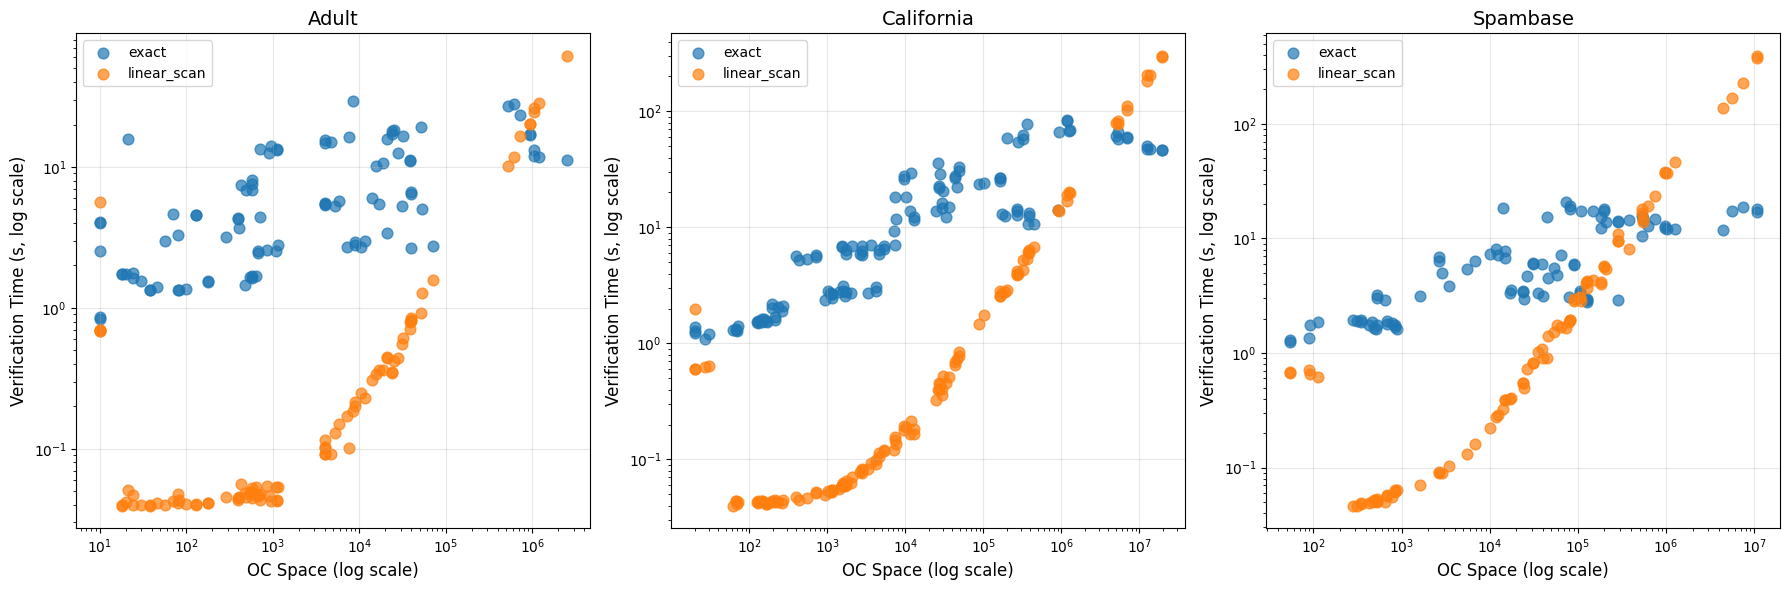

In [5]:
# Plot OC space vs verification time per dataset for linear scan results
import matplotlib.pyplot as plt
import pandas as pd

# Get unique datasets
unique_datasets = sorted(datasets)
n_datasets = len(unique_datasets)

# Create subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, dataset in enumerate(unique_datasets):
    if i < len(axes):
        # Filter data for this dataset
        dataset_data = []
        
        for key, result in results_practical_metrics.items():
            if key.split('_')[0] == dataset:
                # Extract data from each verification
                verification = result['refinements'][0]['verification_results']

                oc_space = verification['oc_space']
                ver_time = verification['exact_emp_rob_time']
                ver_time_linear = verification['exact_emp_rob_linear_scan_time']
                dataset_data.append([oc_space, ver_time, ver_time_linear])
        
        if dataset_data:
            # Convert to DataFrame for easier plotting
            df_plot = pd.DataFrame(dataset_data, columns=['oc_space', 'ver_time', 'ver_time_linear'])
            
            # Create scatter plot with different colors for different methods
            axes[i].scatter(df_plot['oc_space'], df_plot['ver_time'], label='exact', alpha=0.7, s=60)
            axes[i].scatter(df_plot['oc_space'], df_plot['ver_time_linear'], label='linear_scan', alpha=0.7, s=60)
        
            # Set log scales
            axes[i].set_xscale('log')
            axes[i].set_yscale('log')
            
            # Labels and title
            axes[i].set_xlabel('OC Space (log scale)', fontsize=12)
            axes[i].set_ylabel('Verification Time (s, log scale)', fontsize=12)
            axes[i].set_title(f'{dataset}', fontsize=14)
            axes[i].grid(True, alpha=0.3)
            axes[i].legend()

plt.tight_layout()
plt.savefig('plots/linear_scan_oc_space_vs_ver_time_per_dataset.png', dpi=300, bbox_inches='tight')
plt.show()

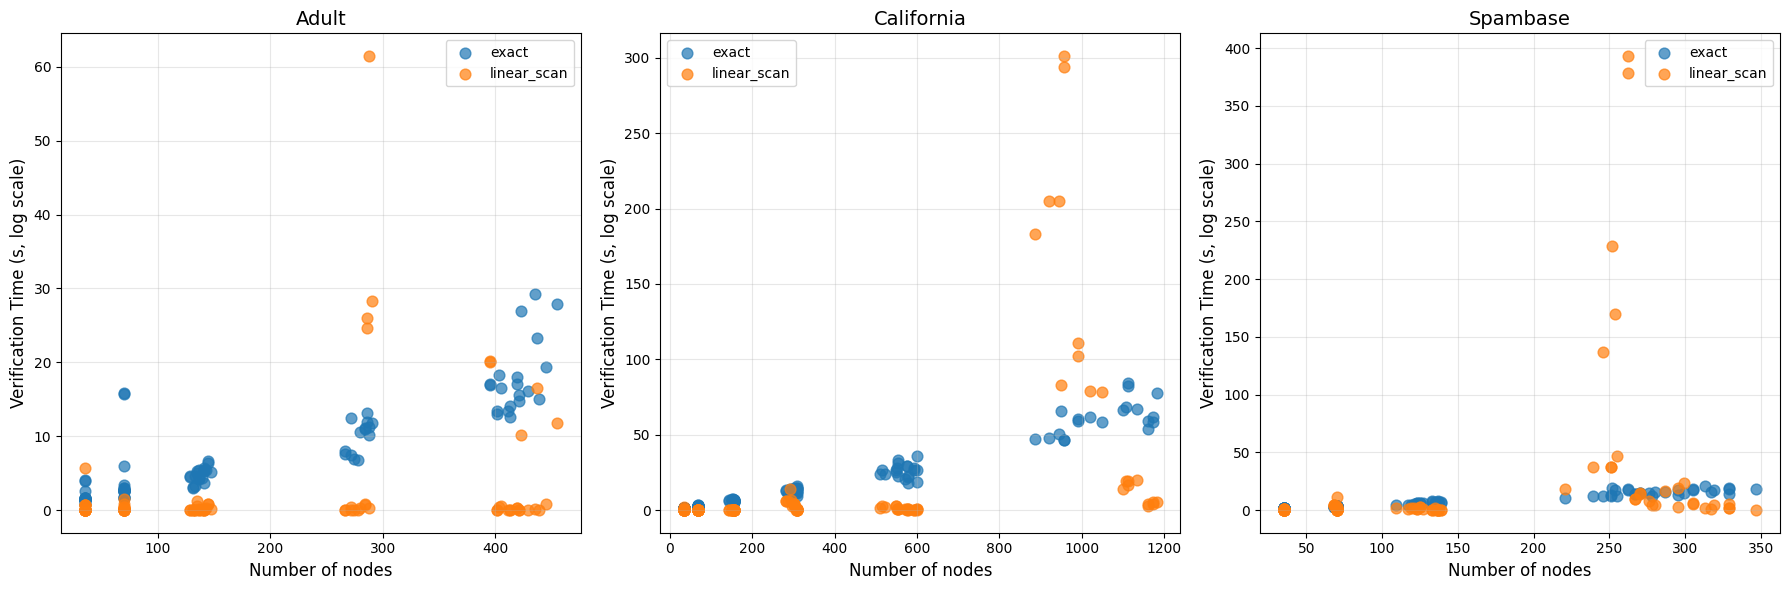

In [6]:
# Plot n_nodes vs exact verification time per dataset
import matplotlib.pyplot as plt
import pandas as pd

# Get unique datasets
unique_datasets = sorted(datasets)
n_datasets = len(unique_datasets)

# Create subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, dataset in enumerate(unique_datasets):
    if i < len(axes):
        # Filter data for this dataset
        dataset_data = []
        
        for key, result in results_practical_metrics.items():
            if key.split('_')[0] == dataset:
                # Extract data from each verification
                verification = result['refinements'][0]['verification_results']
                n_nodes = result['refinements'][0]['nnodes']
                ver_time = verification['exact_emp_rob_time']
                ver_time_linear = verification['exact_emp_rob_linear_scan_time']
                dataset_data.append([n_nodes, ver_time, ver_time_linear])

        if dataset_data:
            # Convert to DataFrame for easier plotting
            df_plot = pd.DataFrame(dataset_data, columns=['n_nodes', 'ver_time', 'ver_time_linear'])

            # Create scatter plot with different colors for different methods
            axes[i].scatter(df_plot['n_nodes'], df_plot['ver_time'], label='exact', alpha=0.7, s=60)
            axes[i].scatter(df_plot['n_nodes'], df_plot['ver_time_linear'], label='linear_scan', alpha=0.7, s=60)

            # Set log scales
            # axes[i].set_xscale('log')
            # axes[i].set_yscale('log')
            
            # Labels and title
            axes[i].set_xlabel('Number of nodes', fontsize=12)
            axes[i].set_ylabel('Verification Time (s, log scale)', fontsize=12)
            axes[i].set_title(f'{dataset}', fontsize=14)
            axes[i].grid(True, alpha=0.3)
            axes[i].legend()

plt.tight_layout()
plt.savefig('plots/linear_scan_oc_space_vs_ver_time_per_dataset_n_nodes.png', dpi=300, bbox_inches='tight')
plt.show()

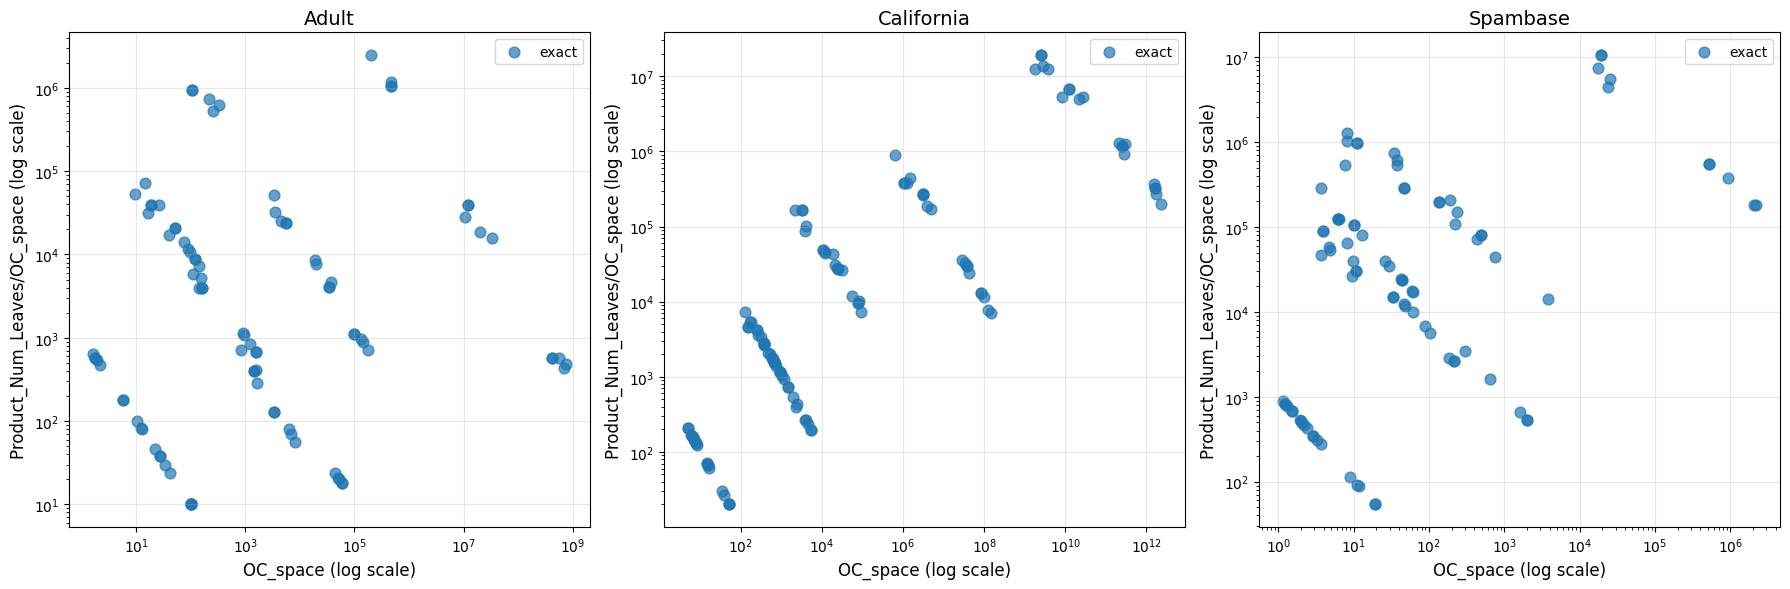

In [10]:
# Plot ratio oc_bound/oc_space vs oc_space per dataset
# Get unique datasets
unique_datasets = sorted(datasets)
n_datasets = len(unique_datasets)

# Create subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, dataset in enumerate(unique_datasets):
    if i < len(axes):
        # Filter data for this dataset
        dataset_data = []
        
        for key, result in results_practical_metrics.items():
            if key.split('_')[0] == dataset:
                # Extract data from each verification
                oc_space_bound = result['refinements'][0]['oc_space_bound'][1]
                oc_space = result['refinements'][0]['verification_results']['oc_space']
                ratio = oc_space_bound / oc_space
                dataset_data.append([ratio, oc_space])

        if dataset_data:
            # Convert to DataFrame for easier plotting
            df_plot = pd.DataFrame(dataset_data, columns=['oc_space_ratio', 'oc_space'])

            # Create scatter plot with different colors for different methods
            axes[i].scatter(df_plot['oc_space_ratio'], df_plot['oc_space'], label='exact', alpha=0.7, s=60)
            # axes[i].scatter(df_plot['n_nodes'], df_plot['ver_time_linear'], label='linear_scan', alpha=0.7, s=60)

            # Set log scales
            axes[i].set_xscale('log')
            axes[i].set_yscale('log')
            
            # Labels and title
            axes[i].set_xlabel('OC_space (log scale)', fontsize=12)
            axes[i].set_ylabel('Product_Num_Leaves/OC_space (log scale)', fontsize=12)
            axes[i].set_title(f'{dataset}', fontsize=14)
            axes[i].grid(True, alpha=0.3)
            axes[i].legend()

plt.tight_layout()
plt.savefig('plots/oc_space_ratio_vs_oc_space_per_dataset.png', dpi=300, bbox_inches='tight')
plt.show()

In [41]:
import json
results_practical_metrics = {}
# datasets = set()
with open('results/practical_metrics.txt', 'r') as file:
    for line in file:
        if not line.startswith('{'):
            continue
        line_dict = json.loads(line.strip())
        key = f"{line_dict['dname']}_{line_dict['n_estimators']}_{line_dict['depth']}_{line_dict['lr']}_{line_dict['fold']}"
        results_practical_metrics[key] = line_dict
        # datasets.add(line_dict['dname'])

In [42]:
results_xgb = {}
with open('results/xgb_classification_saved.txt', 'r') as file:
    for line in file:
        if not line.startswith('{'):
            continue
        line_dict = json.loads(line.strip())
        key = f"{line_dict['dname']}_{line_dict['params']['n_estimators']}_{line_dict['params']['max_depth']}_{line_dict['params']['learning_rate']}_{line_dict['fold']}"
        results_xgb[key] = line_dict

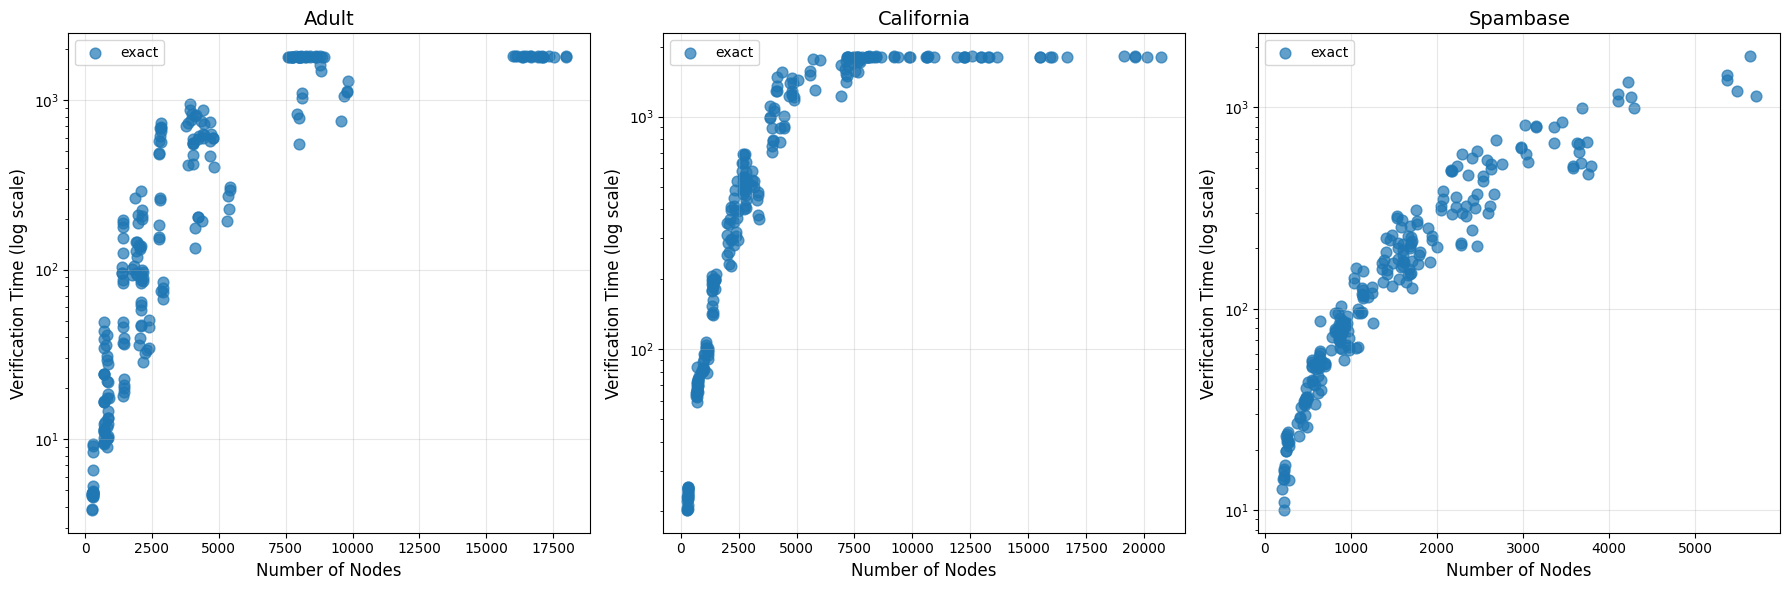

In [45]:
# Plot verification time vs number of nodes per dataset
# Get unique datasets
unique_datasets = sorted(datasets)
n_datasets = len(unique_datasets)

# Create subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, dataset in enumerate(unique_datasets):
    if i < len(axes):
        # Filter data for this dataset
        dataset_data = []
        
        for key, result in results_practical_metrics.items():
            if key.split('_')[0] == dataset:
                # Extract data from each verification
                ver_time = result['verifications'][0]['verification_results']['exact_emp_rob_time']
                n_nodes = results_xgb[key]['nnodes']
                dataset_data.append([n_nodes, ver_time])

        if dataset_data:
            # Convert to DataFrame for easier plotting
            df_plot = pd.DataFrame(dataset_data, columns=['n_nodes', 'ver_time'])

            # Create scatter plot with different colors for different methods
            axes[i].scatter(df_plot['n_nodes'], df_plot['ver_time'], label='exact', alpha=0.7, s=60)
            # axes[i].scatter(df_plot['n_nodes'], df_plot['ver_time_linear'], label='linear_scan', alpha=0.7, s=60)

            # Set log scales
            # axes[i].set_xscale('log')
            axes[i].set_yscale('log')
            
            # Labels and title
            axes[i].set_xlabel('Number of Nodes', fontsize=12)
            axes[i].set_ylabel('Verification Time (log scale)', fontsize=12)
            axes[i].set_title(f'{dataset}', fontsize=14)
            axes[i].grid(True, alpha=0.3)
            axes[i].legend()

plt.tight_layout()
plt.savefig('plots/exact_verification_time_vs_n_nodes_per_dataset.png', dpi=300, bbox_inches='tight')
plt.show()

## Check how many pareto front models we were able to enumerate

In [1]:
import json
results_horse_race = {}
datasets = set()
with open('results/xgb_classification_saved.txt', 'r') as file: #Load in the XGB classification results
    for line in file:
        if not line.startswith('{'):
            continue
        line_dict = json.loads(line.strip())
        key = f"{line_dict['dname']}_{line_dict['params']['n_estimators']}_{line_dict['params']['max_depth']}_{line_dict['params']['learning_rate']}_{line_dict['fold']}"
        results_horse_race[key] = line_dict
        datasets.add(line_dict['dname'])

In [2]:
results_verification_pareto = {}
with open('results/linear_scan_LOP_pareto1.txt', 'r') as file: #Load in the linear scan results
    for line in file:
        if not line.startswith('{'):
            continue
        line_dict = json.loads(line.strip())
        key = f"{line_dict['dname']}_{line_dict['params']['n_estimators']}_{line_dict['params']['max_depth']}_{line_dict['params']['learning_rate']}_{line_dict['fold']}"
        results_verification_pareto[key] = line_dict

with open('results/linear_scan_LOP_pareto2.txt', 'r') as file: #Load in the linear scan results
    for line in file:
        if not line.startswith('{'):
            continue
        line_dict = json.loads(line.strip())
        key = f"{line_dict['dname']}_{line_dict['params']['n_estimators']}_{line_dict['params']['max_depth']}_{line_dict['params']['learning_rate']}_{line_dict['fold']}"
        results_verification_pareto[key] = line_dict

In [3]:
import pickle
import os
import util

# Save pareto fronts to file if it doesn't exist
pareto_fronts_file = 'pareto_fronts_LOP.pkl'

if not os.path.exists(pareto_fronts_file):
    pareto_fronts = {}
    
    for d, ds in enumerate(datasets):
        df = []
        for depth in [4, 6, 8]:
            for n_estimators in [10, 25, 50, 100]:
                for lr in [0.1, 0.25, 0.5, 1.0]:
                    avg_mtest = 0
                    avg_nleafs = 0
                    for fold in range(5):
                        key = f"{ds}_{n_estimators}_{depth}_{lr}_{fold}"
                        if key in results_horse_race:
                            avg_mtest += results_horse_race[key]['refinements'][-2]['mtest']/5
                            avg_nleafs += results_horse_race[key]['refinements'][-2]['nleafs']/5
                    df.append(np.array([depth, n_estimators, lr, avg_mtest, avg_nleafs]))

        df = pd.DataFrame(np.array(df), columns=['max_depth', 'n_estimators', 'learning_rate', 'mtest', 'nleafs'])
        on_front, on_hull = util.pareto_front_xy(df['nleafs'].to_numpy(), df['mtest'].to_numpy())
        
        df['on_front'] = on_front
        df['on_hull'] = on_hull
        
        pareto_fronts[ds] = df
    
    # Save to pickle file
    with open(pareto_fronts_file, 'wb') as f:
        pickle.dump(pareto_fronts, f)
    
    print(f"Pareto fronts saved to {pareto_fronts_file}")
else:
    # Load existing pareto fronts
    with open(pareto_fronts_file, 'rb') as f:
        pareto_fronts = pickle.load(f)
    
    print(f"Pareto fronts loaded from {pareto_fronts_file}")

Pareto fronts loaded from pareto_fronts_LOP.pkl


In [5]:
import pickle
import os
import util

# Save pareto fronts to file if it doesn't exist
pareto_fronts_file = 'pareto_fronts_XGB.pkl'

if not os.path.exists(pareto_fronts_file):
    pareto_fronts = {}
    
    for d, ds in enumerate(datasets):
        df = []
        for depth in [4, 6, 8]:
            for n_estimators in [10, 25, 50, 100]:
                for lr in [0.1, 0.25, 0.5, 1.0]:
                    avg_mtest = 0
                    avg_nleafs = 0
                    for fold in range(5):
                        key = f"{ds}_{n_estimators}_{depth}_{lr}_{fold}"
                        if key in results_horse_race:
                            avg_mtest += results_horse_race[key]['mtest']/5
                            avg_nleafs += results_horse_race[key]['nleafs']/5
                    df.append(np.array([depth, n_estimators, lr, avg_mtest, avg_nleafs]))

        df = pd.DataFrame(np.array(df), columns=['max_depth', 'n_estimators', 'learning_rate', 'mtest', 'nleafs'])
        on_front, on_hull = util.pareto_front_xy(df['nleafs'].to_numpy(), df['mtest'].to_numpy())
        
        df['on_front'] = on_front
        df['on_hull'] = on_hull
        
        pareto_fronts[ds] = df
    
    # Save to pickle file
    with open(pareto_fronts_file, 'wb') as f:
        pickle.dump(pareto_fronts, f)
    
    print(f"Pareto fronts saved to {pareto_fronts_file}")
else:
    # Load existing pareto fronts
    with open(pareto_fronts_file, 'rb') as f:
        pareto_fronts = pickle.load(f)
    
    print(f"Pareto fronts loaded from {pareto_fronts_file}")

Pareto fronts loaded from pareto_fronts_XGB.pkl


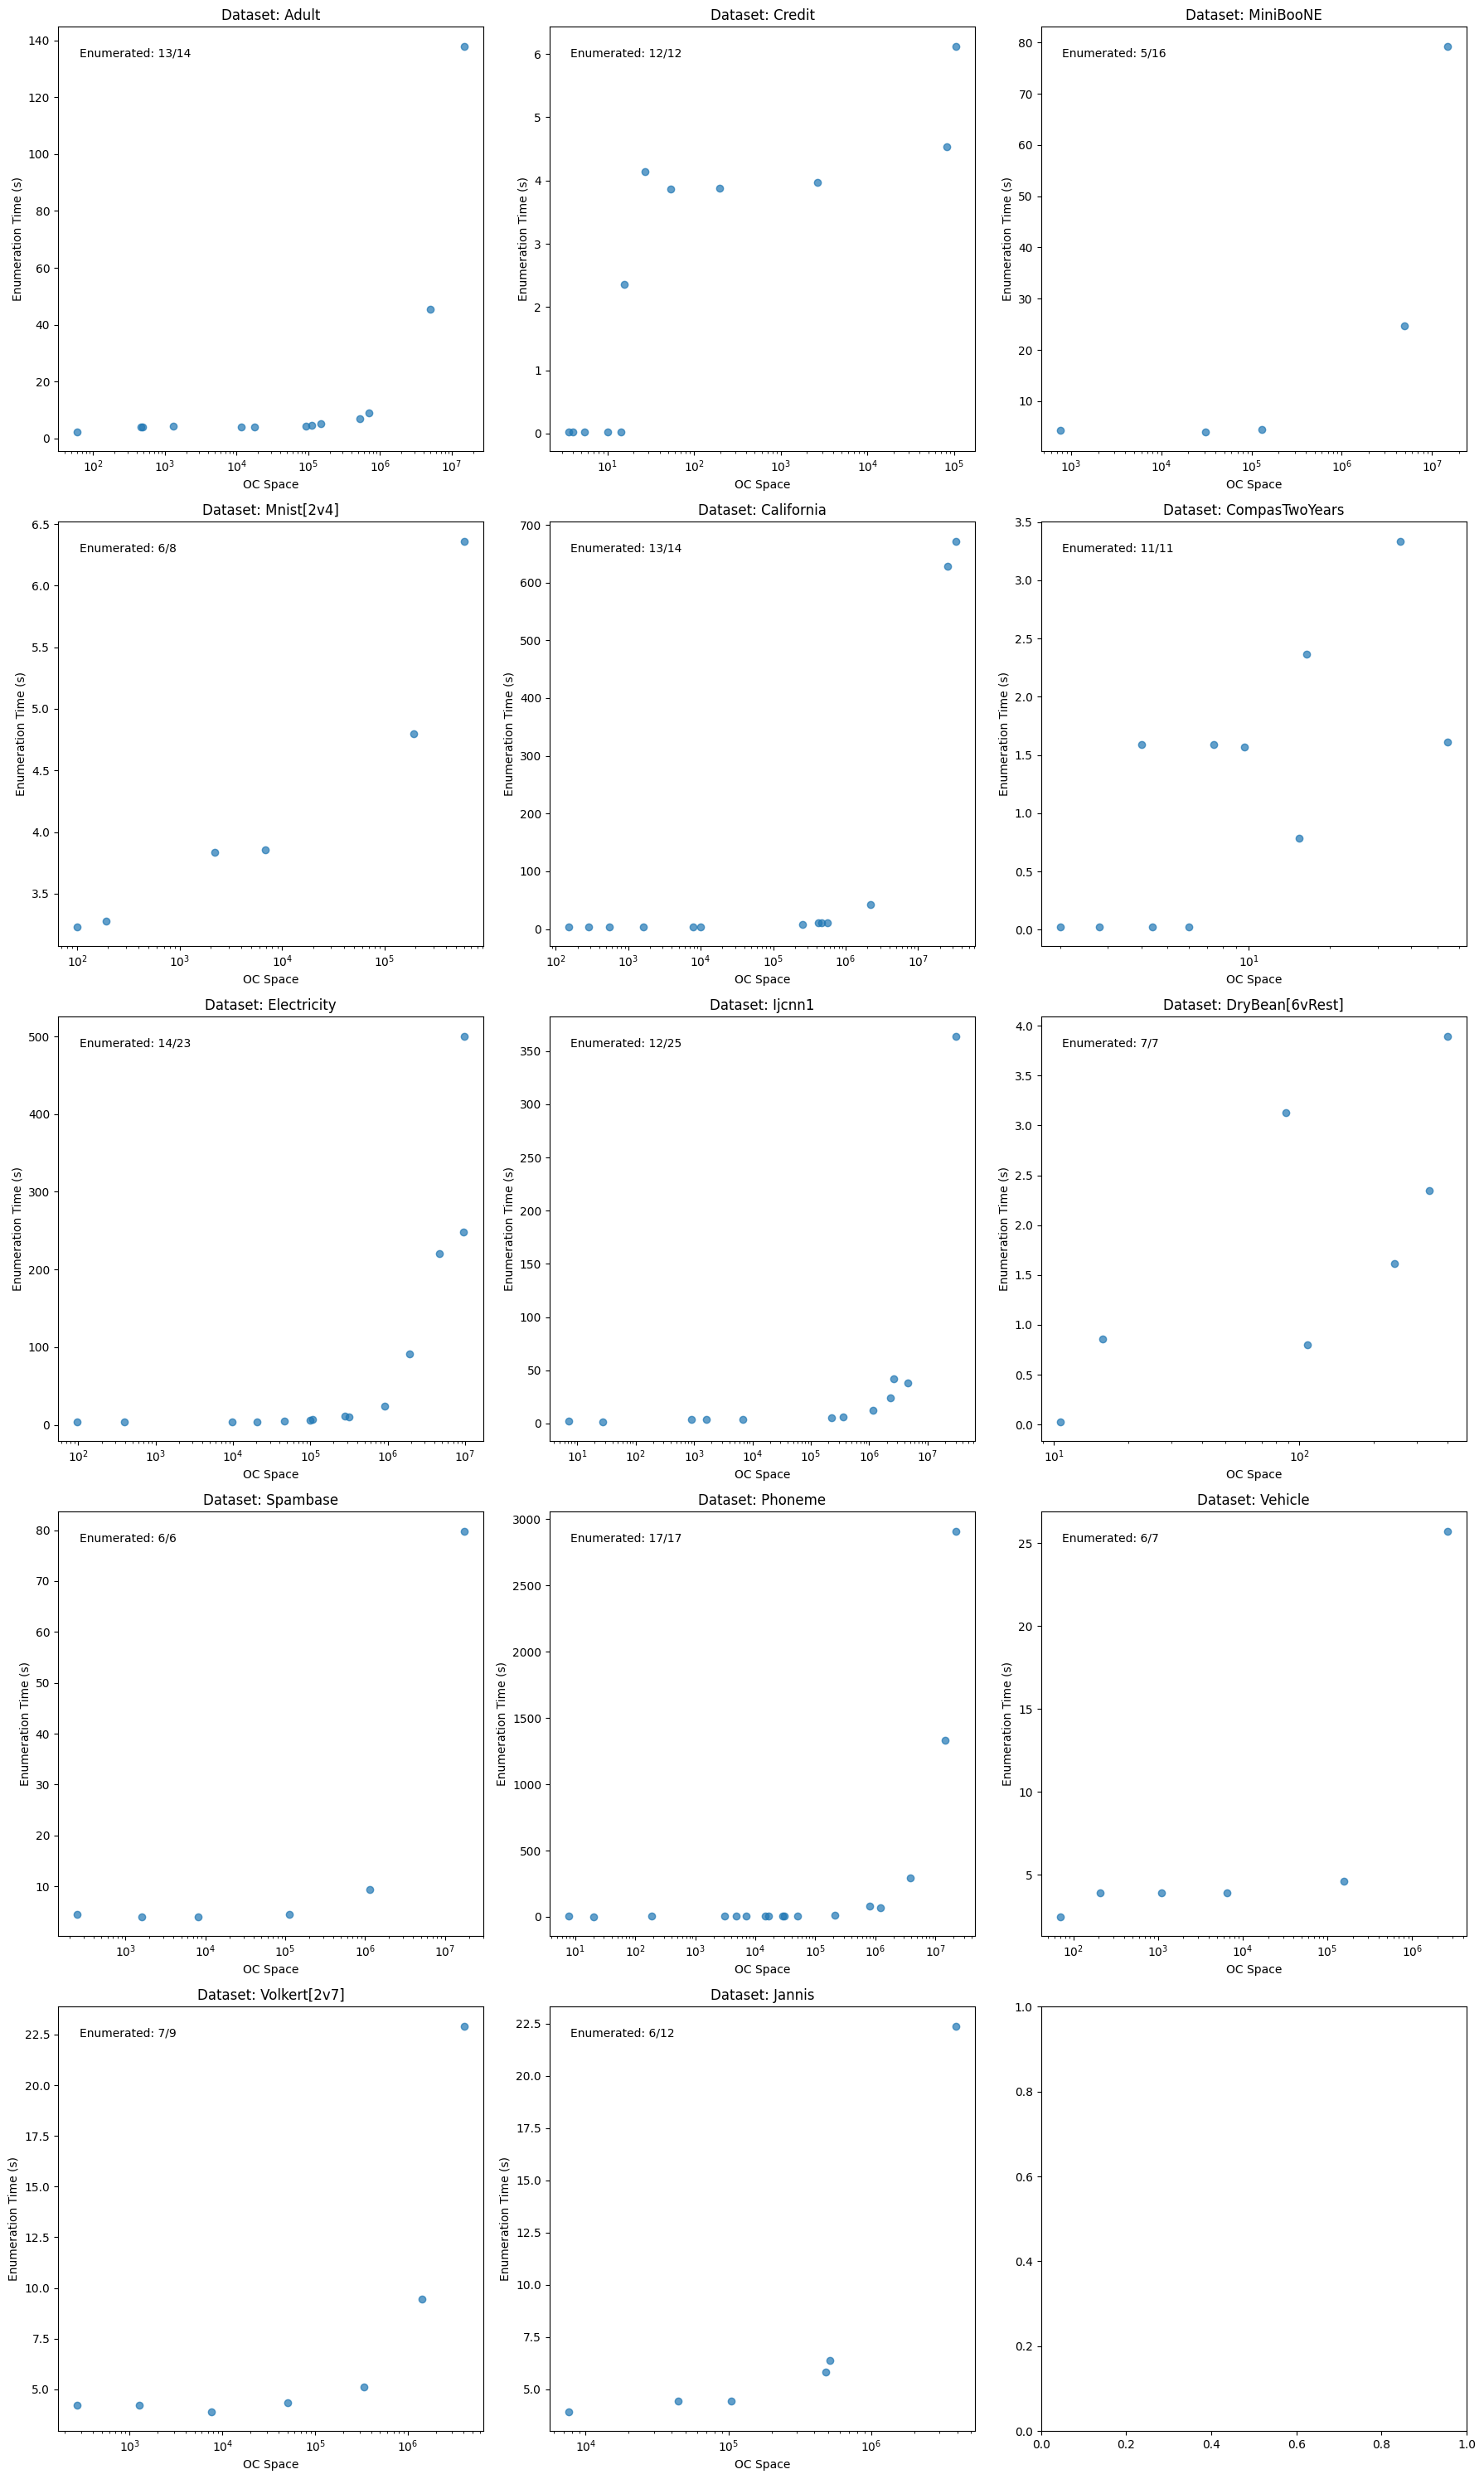

In [17]:
# Find keys on pareto front of XGBoost models using stored pareto fronts
# These are fronts, not hulls which is different from what we plotted in the LOP paper
from matplotlib import pyplot as plt
# Calculate grid dimensions
n_datasets = len(datasets)
n_cols = min(3, n_datasets)  # Max 3 columns
n_rows = (n_datasets + n_cols - 1) // n_cols  # Calculate rows needed

# Create subplots in matrix format
fig, axes = plt.subplots(n_rows, n_cols, figsize=(6*n_cols, 6*n_rows))

# Handle single subplot case
if n_datasets == 1:
    axes = [axes]
elif n_rows == 1:
    axes = axes.reshape(1, -1)
elif n_cols == 1:
    axes = axes.reshape(-1, 1)

# Flatten for easier indexing
axes_flat = axes.flatten() if n_datasets > 1 else axes

for d, ds in enumerate(datasets):
    df = pareto_fronts[ds]
    
    cnt_enumerated = 0
    cnt_total = 0
    oc_space_sizes = []
    enumeration_times = []
    for row in df.iterrows():

        if row[1]['on_front']:
            depth = int(row[1]['max_depth'])
            n_estimators = int(row[1]['n_estimators'])
            lr = row[1]['learning_rate']
            key_base = f"{ds}_{n_estimators}_{depth}_{lr}_"

            failed = False
            enumeration_time = 0.0
            oc_space_size = 0.0
            
            for fold in range(5):
                key = key_base + str(fold)
                verification_result = results_verification_pareto.get(key, None)['compression']['verification_results']
                failed |= verification_result['failed_oc']
                enumeration_time += verification_result.get('time_taken_oc', 0.0)
                oc_space_size += verification_result.get('oc_space', 0.0)

            if not failed:
                cnt_enumerated += 1
                enumeration_times.append(enumeration_time/5)
                oc_space_sizes.append(oc_space_size/5)

            cnt_total += 1

    axes_flat[d].plot(oc_space_sizes, enumeration_times, 'o', alpha=0.7)
    axes_flat[d].set_title(f"Dataset: {ds}")
    axes_flat[d].set_xlabel('OC Space')
    axes_flat[d].set_ylabel('Enumeration Time (s)')
    axes_flat[d].set_xscale('log')
    axes_flat[d].text(0.05, 0.95, f"Enumerated: {cnt_enumerated}/{cnt_total}", transform=axes_flat[d].transAxes, 
                      verticalalignment='top')

plt.tight_layout()
plt.savefig('plots/pareto_front_enumeration_times.pdf', dpi=300, bbox_inches='tight')
    # print(f"Dataset: {ds}, Completed: {nb_front_completed}, Memory faults: {nb_memory_faults}, Timeouts: {nb_timeouts}, Total on front: {sum(df['on_front'])}")


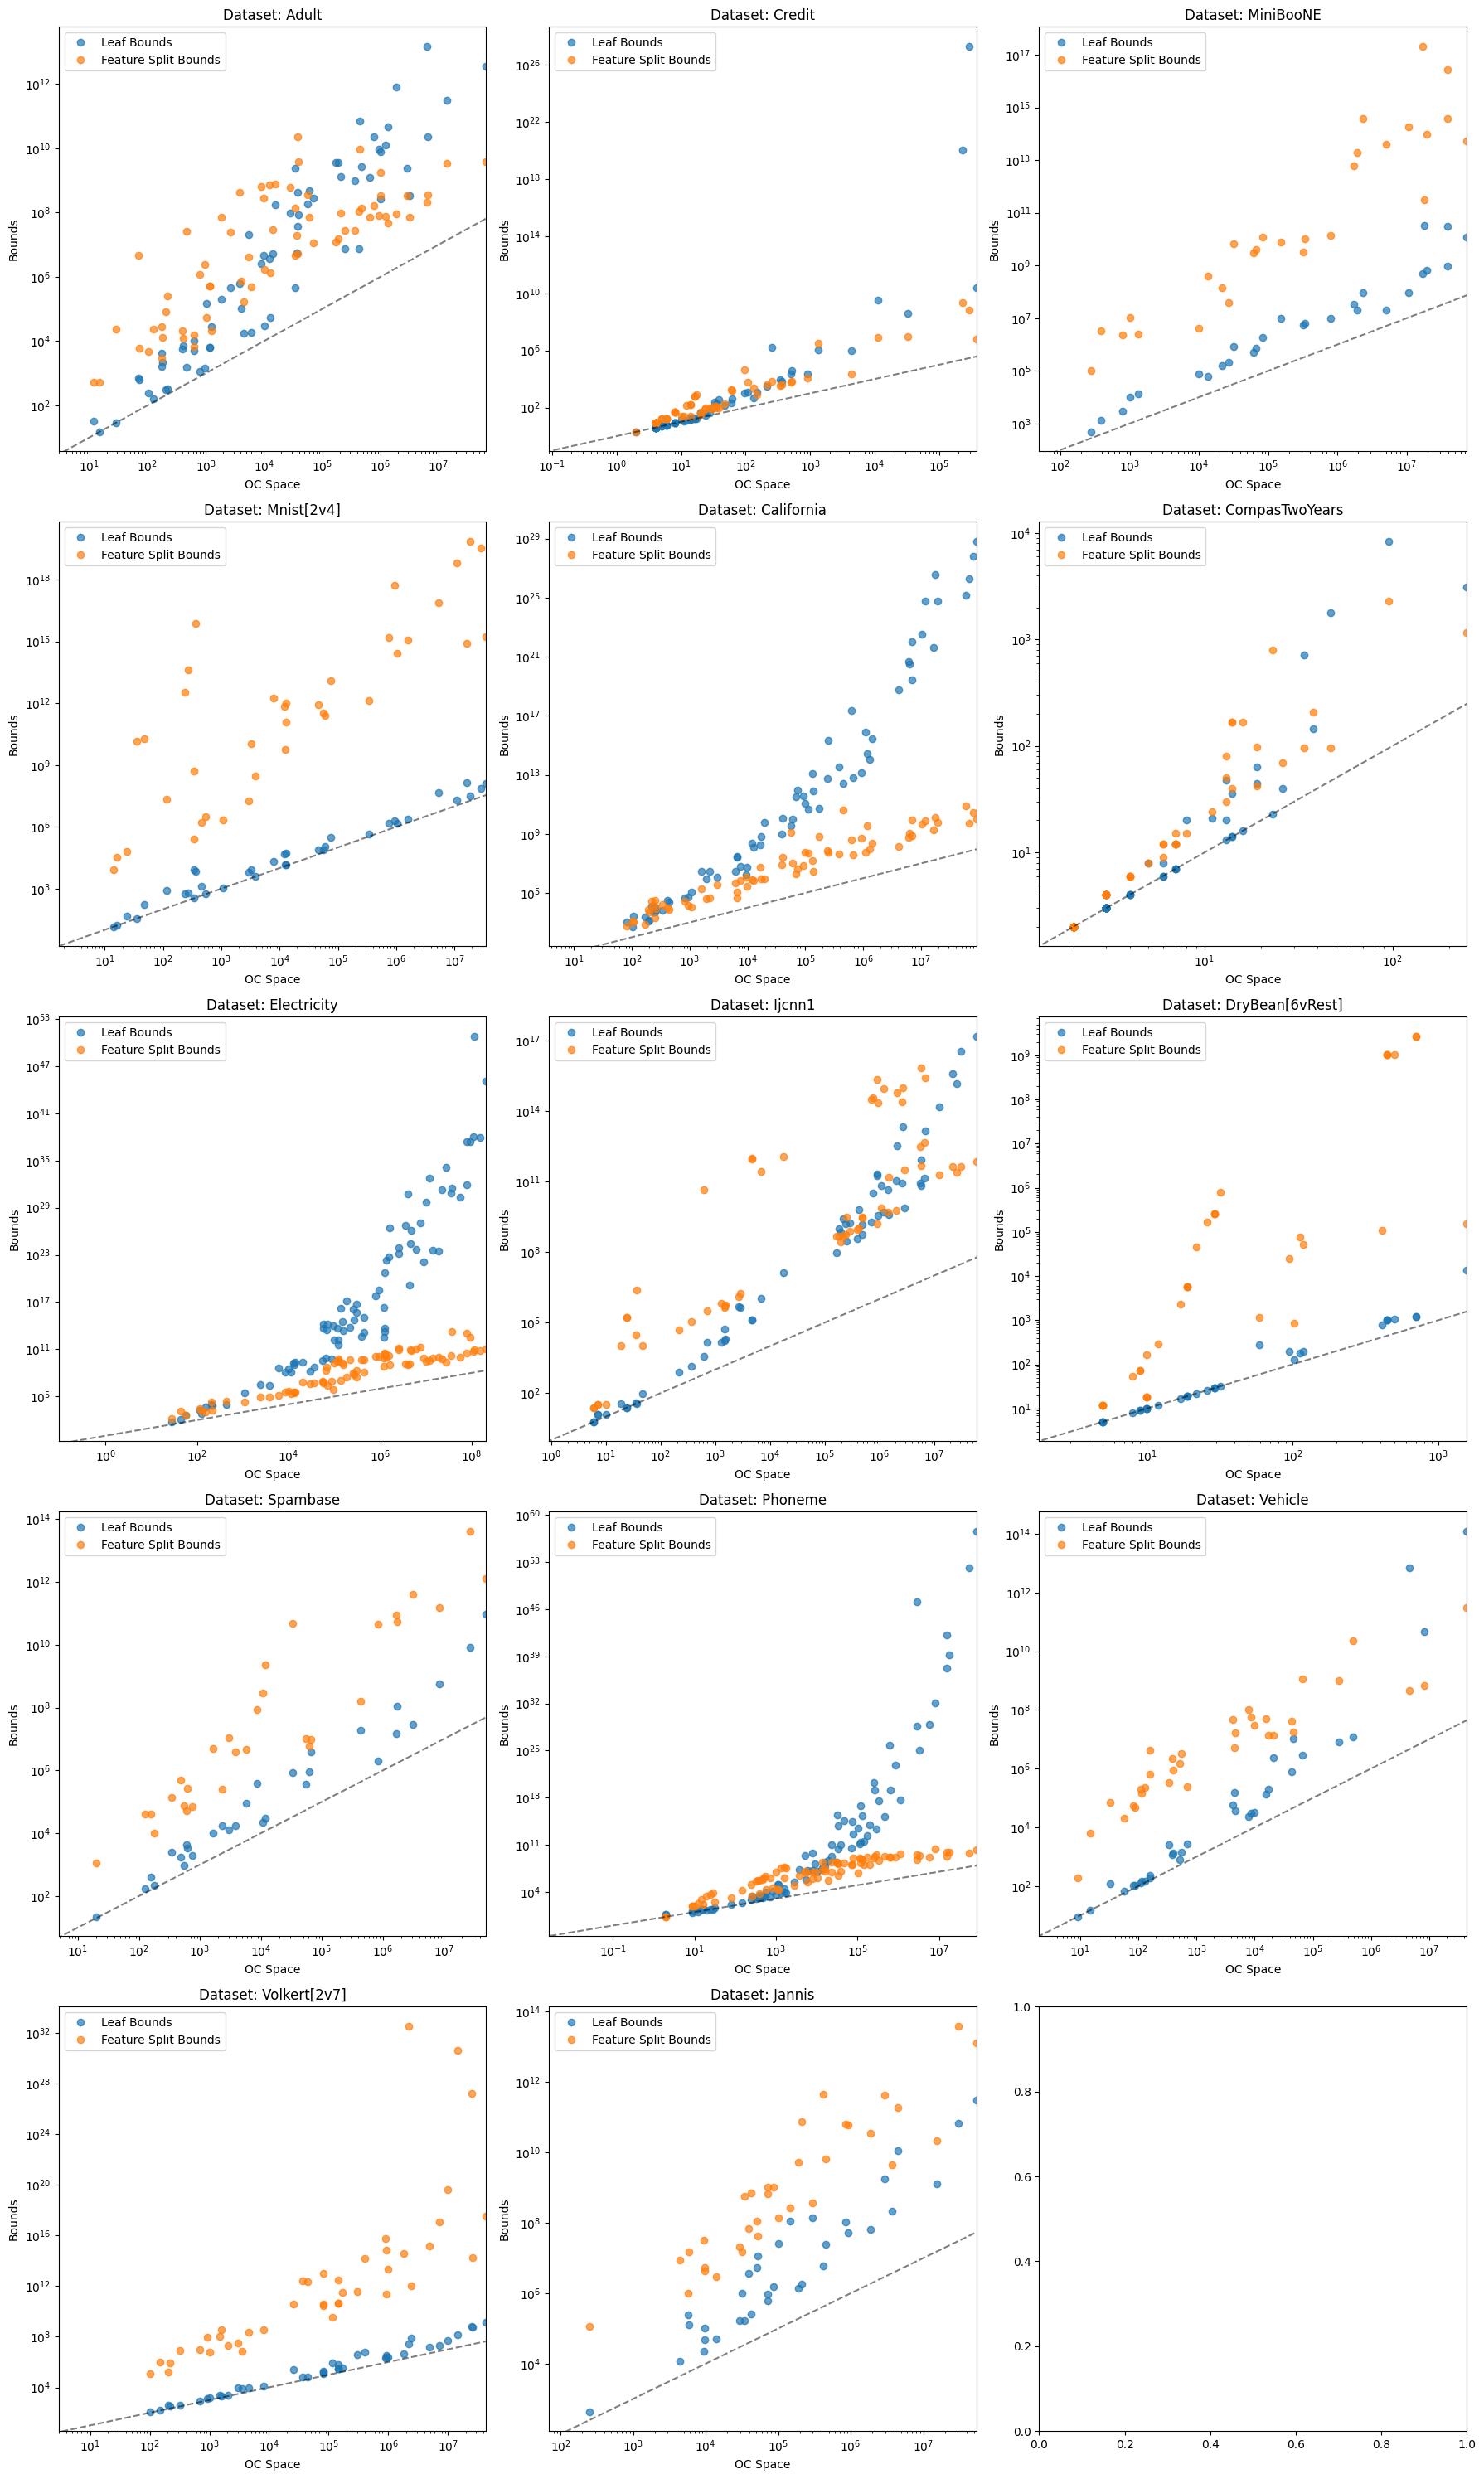

In [20]:
# Find keys on pareto front of XGBoost models using stored pareto fronts
# These are fronts, not hulls which is different from what we plotted in the LOP paper
from matplotlib import pyplot as plt
# Calculate grid dimensions
n_datasets = len(datasets)
n_cols = min(3, n_datasets)  # Max 3 columns
n_rows = (n_datasets + n_cols - 1) // n_cols  # Calculate rows needed

# Create subplots in matrix format
fig, axes = plt.subplots(n_rows, n_cols, figsize=(6*n_cols, 6*n_rows))

# Handle single subplot case
if n_datasets == 1:
    axes = [axes]
elif n_rows == 1:
    axes = axes.reshape(1, -1)
elif n_cols == 1:
    axes = axes.reshape(-1, 1)

# Flatten for easier indexing
axes_flat = axes.flatten() if n_datasets > 1 else axes

for d, ds in enumerate(datasets):
    df = pareto_fronts[ds]

    oc_space_sizes = []
    bounds_n_leafs = []
    bounds_n_feature_splits = []
    for row in df.iterrows():

        if row[1]['on_front']:
            depth = int(row[1]['max_depth'])
            n_estimators = int(row[1]['n_estimators'])
            lr = row[1]['learning_rate']
            key_base = f"{ds}_{n_estimators}_{depth}_{lr}_"
            
            for fold in range(5):
                key = key_base + str(fold)
                verification_result = results_verification_pareto.get(key, None)['compression']
                if not verification_result['verification_results']['failed_oc']:
                    bounds_n_leafs.append(verification_result['oc_space_bound'][1])
                    bounds_n_feature_splits.append(verification_result['oc_space_bound'][0])
                    oc_space_sizes.append(verification_result['verification_results']['oc_space'])

    axes_flat[d].plot(oc_space_sizes, bounds_n_leafs, 'o', label='Leaf Bounds', alpha=0.7)
    axes_flat[d].plot(oc_space_sizes, bounds_n_feature_splits, 'o', label='Feature Split Bounds', alpha=0.7)
    axes_flat[d].plot()
    axes_flat[d].set_title(f"Dataset: {ds}")
    axes_flat[d].set_xlabel('OC Space')
    axes_flat[d].set_ylabel('Bounds')
    axes_flat[d].set_xscale('log')
    axes_flat[d].set_yscale('log')
    axes_flat[d].legend()
    # Add diagonal reference line
    lim = max(max(bounds_n_leafs), max(bounds_n_feature_splits), max(oc_space_sizes))
    axes_flat[d].plot([0, lim], [0, lim], 'k--', alpha=0.5, label='y=x')
    axes_flat[d].set_xlim(right=max(oc_space_sizes))
    # axes_flat[d].set_ylim(bottom=1e-1, top=max(max(bounds_n_leafs), max(bounds_n_feature_splits)))

plt.tight_layout()
plt.savefig('plots/pareto_front_bounds_vs_oc_space.pdf', dpi=300, bbox_inches='tight')
    # print(f"Dataset: {ds}, Completed: {nb_front_completed}, Memory faults: {nb_memory_faults}, Timeouts: {nb_timeouts}, Total on front: {sum(df['on_front'])}")


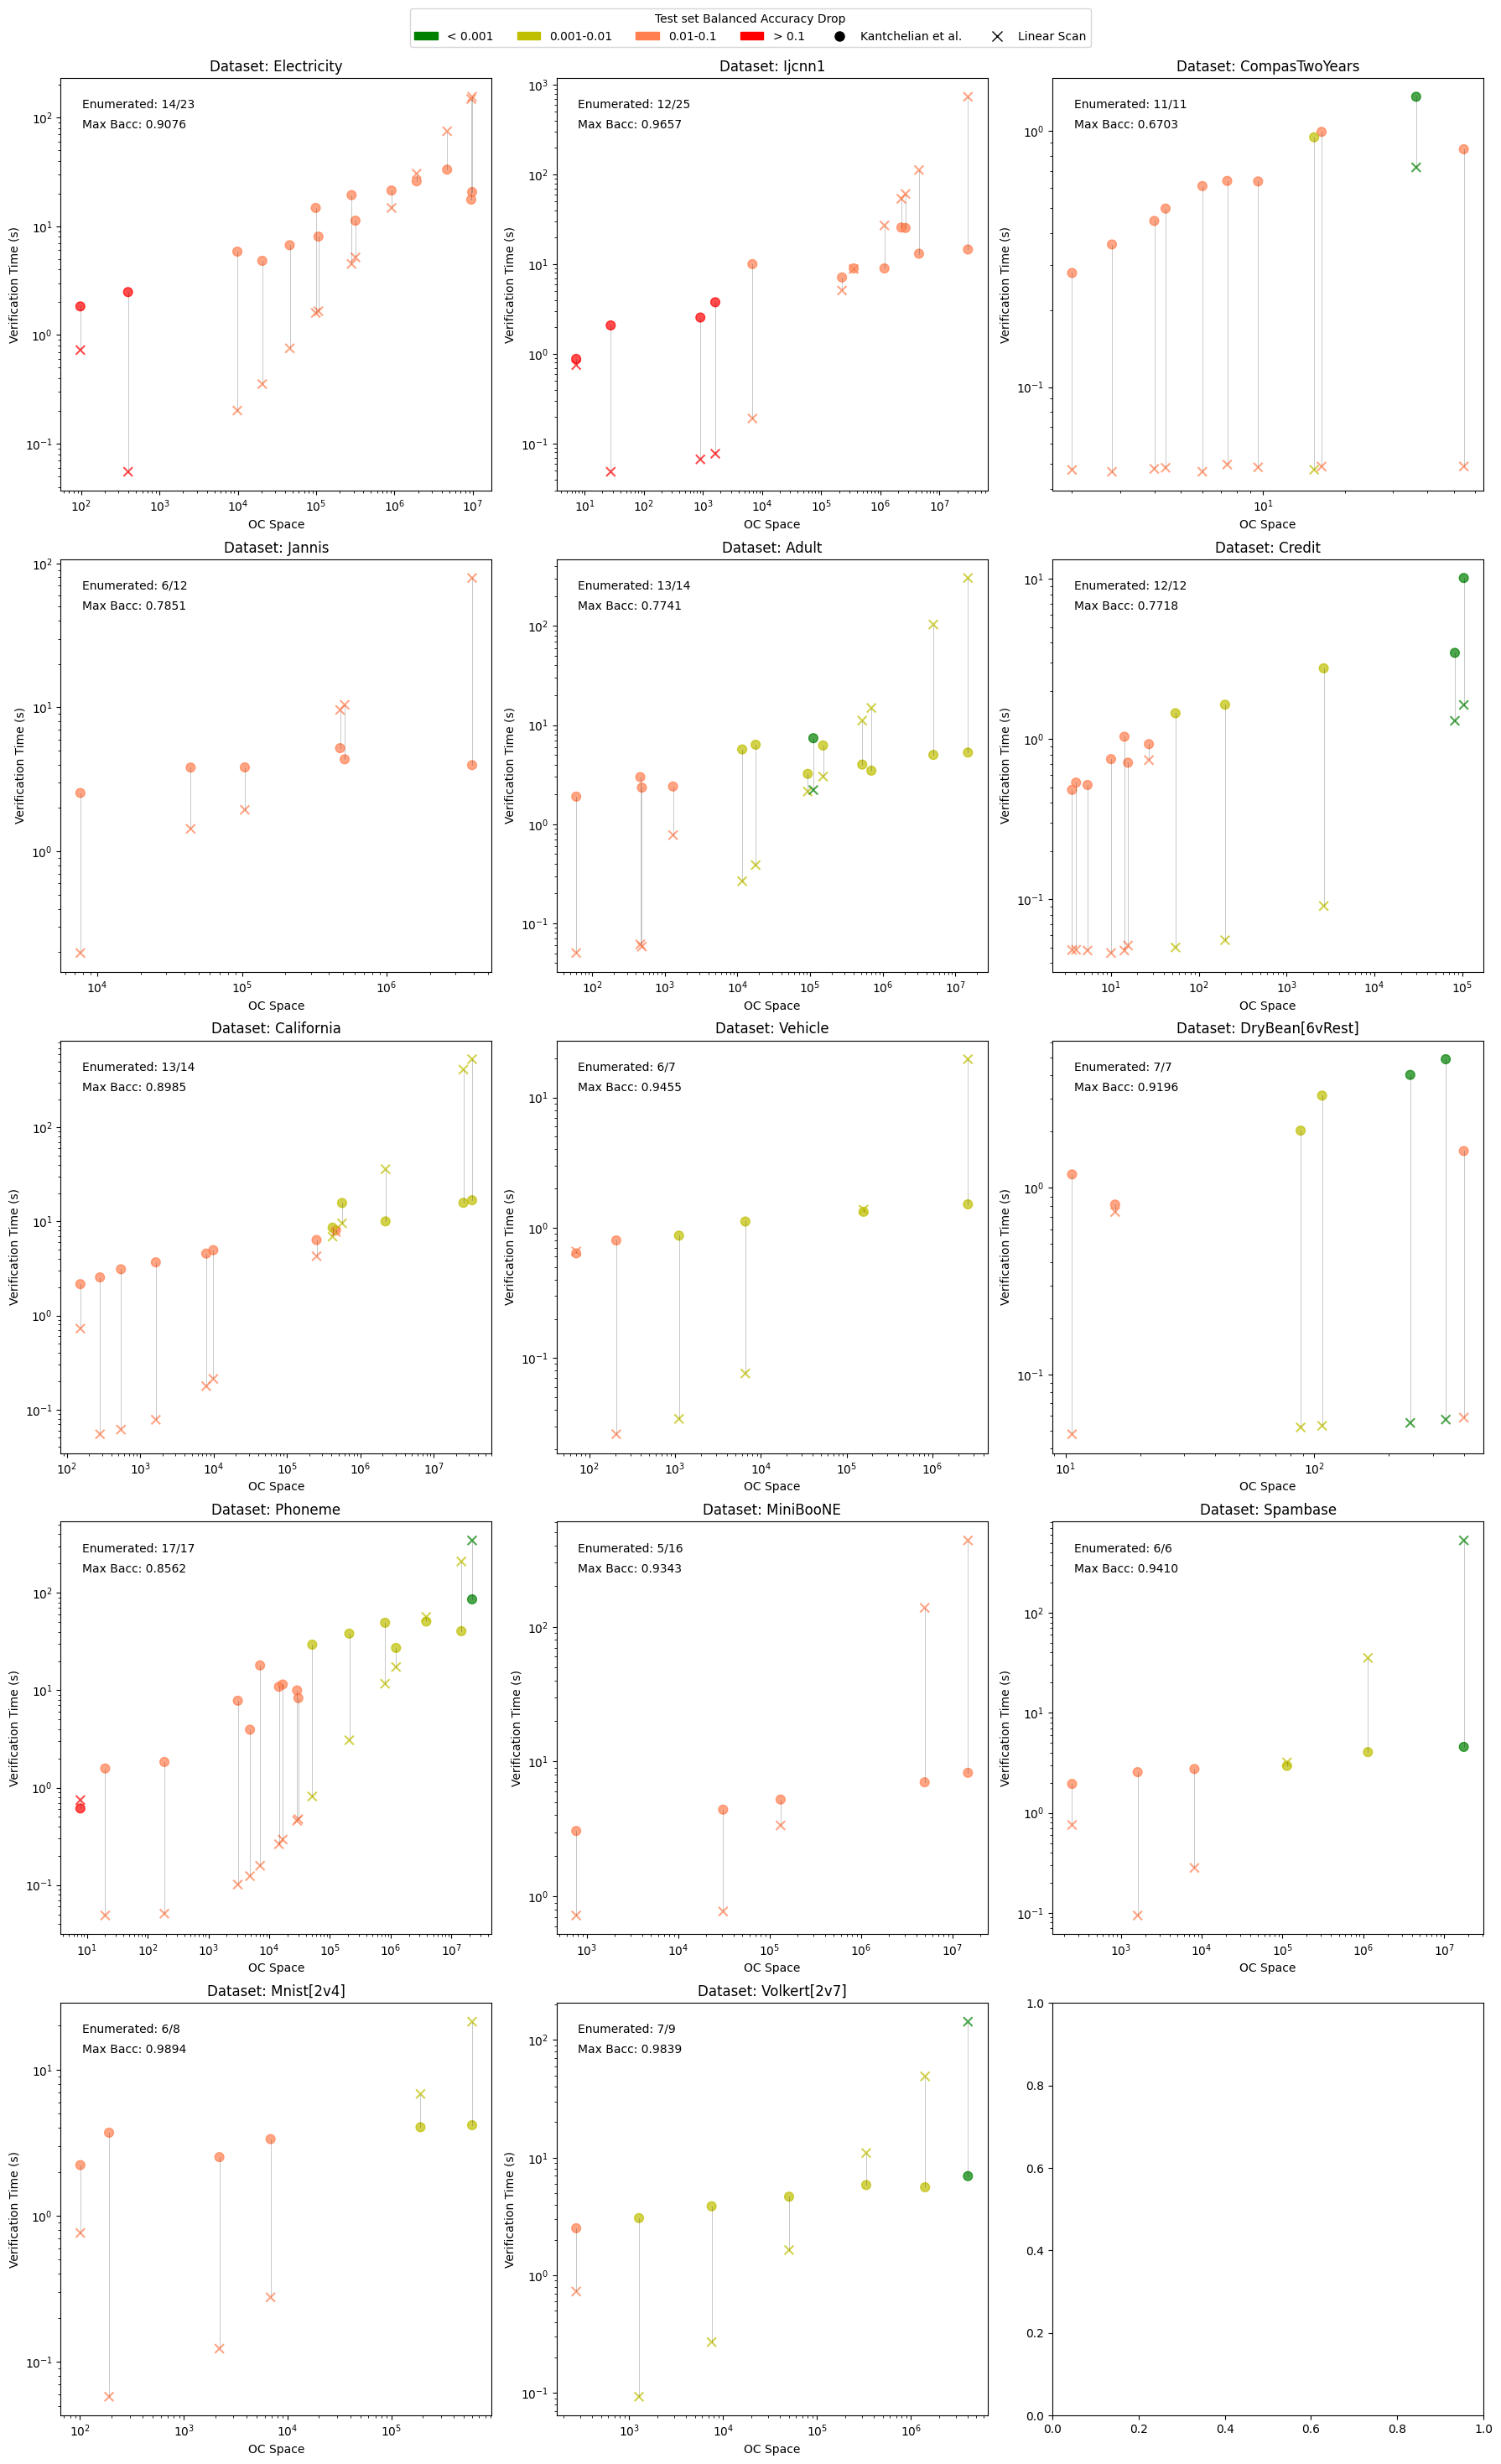

In [4]:
# Find keys on pareto front of XGBoost models using stored pareto fronts
# These are fronts, not hulls which is different from what we plotted in the LOP paper
from matplotlib import pyplot as plt
import numpy as np
from matplotlib.lines import Line2D
# Calculate grid dimensions
n_datasets = len(datasets)
n_cols = min(3, n_datasets)  # Max 3 columns
n_rows = (n_datasets + n_cols - 1) // n_cols  # Calculate rows needed

# Create subplots in matrix format
fig, axes = plt.subplots(n_rows, n_cols, figsize=(6*n_cols, 6*n_rows))

# Handle single subplot case
if n_datasets == 1:
    axes = [axes]
elif n_rows == 1:
    axes = axes.reshape(1, -1)
elif n_cols == 1:
    axes = axes.reshape(-1, 1)

# Flatten for easier indexing
axes_flat = axes.flatten() if n_datasets > 1 else axes

for d, ds in enumerate(datasets):
    df = pareto_fronts[ds]
    
    cnt_enumerated = 0
    cnt_total = 0
    oc_space_sizes = []
    kantchelian_times = []
    linear_scan_times = []
    accuracies = []
    max_accuracy = 0.0
    for row in df.iterrows():

        if row[1]['on_front']:
            depth = int(row[1]['max_depth'])
            n_estimators = int(row[1]['n_estimators'])
            lr = row[1]['learning_rate']
            key_base = f"{ds}_{n_estimators}_{depth}_{lr}_"

            failed = False
            kantchelian_time = 0.0
            linear_scan_time = 0.0
            oc_space_size = 0.0
            accuracy = 0.0
            
            for fold in range(5):
                key = key_base + str(fold)
                verification_result = results_verification_pareto.get(key, None)['compression']['verification_results']
                failed |= verification_result['failed_oc']
                kantchelian_time += verification_result.get('exact_emp_rob_time', 0.0)
                linear_scan_time += verification_result.get('exact_emp_rob_linear_scan_time', 0.0)
                oc_space_size += verification_result.get('oc_space', 0.0)
                accuracy += results_verification_pareto.get(key, None)['compression']['mtest']


            max_accuracy = max(max_accuracy, accuracy/5)
            if not failed:
                cnt_enumerated += 1
                kantchelian_times.append(kantchelian_time/5)
                linear_scan_times.append(linear_scan_time/5)
                oc_space_sizes.append(oc_space_size/5)
                accuracies.append(accuracy/5)

            cnt_total += 1
            # for fold in range(5):
            #     key = key_base + str(fold)
            #     verification_result = results_verification_pareto.get(key, None)['compression']['verification_results']
            #     if not verification_result['failed_oc']:
            #         cnt_enumerated += 1
            #         kantchelian_times.append(verification_result.get('exact_emp_rob_time', 0.0))
            #         linear_scan_times.append(verification_result.get('exact_emp_rob_linear_scan_time', 0.0))
            #         oc_space_sizes.append(verification_result.get('oc_space', 0.0))
            #         accuracy = results_verification_pareto.get(key, None)['compression']['mtest']
            #         accuracies.append(accuracy)
                
            #     max_accuracy = max(max_accuracy, accuracy)
            #     cnt_total += 1
                


    accuracy_diffs = [max_accuracy - acc for acc in accuracies]
    accuracy_colors = ['green' if diff < 0.001 else 'y' if diff < 0.01 else 'coral' if diff < 0.1 else 'red' for diff in accuracy_diffs]

    axes_flat[d].scatter(oc_space_sizes, kantchelian_times, c=accuracy_colors, label='Kantchelian et al.', alpha=0.7, s=60)
    axes_flat[d].scatter(oc_space_sizes, linear_scan_times, marker='x', c=accuracy_colors, label='Linear Scan', alpha=0.7, s=60)
    axes_flat[d].set_title(f"Dataset: {ds}")
    axes_flat[d].set_xlabel('OC Space')
    axes_flat[d].set_ylabel('Verification Time (s)')
    axes_flat[d].set_xscale('log')
    axes_flat[d].set_yscale('log')
    axes_flat[d].text(0.05, 0.95, f"Enumerated: {cnt_enumerated}/{cnt_total}", transform=axes_flat[d].transAxes, 
                      verticalalignment='top')
    axes_flat[d].text(0.05, 0.90, f"Max Bacc: {max_accuracy:.4f}", transform=axes_flat[d].transAxes, 
                        verticalalignment='top')
    # Plot connecting lines between corresponding points
    for i in range(len(oc_space_sizes)):
        axes_flat[d].plot([oc_space_sizes[i], oc_space_sizes[i]], 
                         [kantchelian_times[i], linear_scan_times[i]], 
                         'k-', alpha=0.3, linewidth=0.5)

    # Add legend for colors
    
    
    # Add legend with both line/marker styles and color meanings
    # Add legend for method types (without color)
    

import matplotlib.patches as mpatches
green_patch = mpatches.Patch(color='green', label='< 0.001')
yellow_patch = mpatches.Patch(color='y', label='0.001-0.01')
coral_patch = mpatches.Patch(color='coral', label='0.01-0.1')
red_patch = mpatches.Patch(color='red', label='> 0.1')
kantchelian_line = Line2D([0], [0], marker='o', color='black', label='Kantchelian et al.', linestyle='None', markersize=8)
linear_scan_line = Line2D([0], [0], marker='x', color='black', label='Linear Scan', linestyle='None', markersize=8)
color_legend = fig.legend(handles=[green_patch, yellow_patch, coral_patch, red_patch, kantchelian_line, linear_scan_line], 
                         loc='upper center', bbox_to_anchor=(0.5, 0.98), title='Test set Balanced Accuracy Drop', ncol=6, fontsize=10)


plt.tight_layout()
plt.subplots_adjust(top=0.95)
plt.savefig('plots/pareto_front_verification_times_comparison.pdf', dpi=300, bbox_inches='tight')


In [ ]:
# Make a weighted count of feature usage across all trees in an ensemble
def analyze_feature_usage(at):
    for t in at:
        feature_counts = {}
        
        def traverse_tree(t, node):
            print(t.get_split(node))
            # if 'split_condition' in node:
            #     feature_id = node['split_condition']['feature_id']
            #     if feature_id not in feature_counts:
            #         feature_counts[feature_id] = 0
            #     feature_counts[feature_id] += 1
            #     if 'yes' in node:
            #         traverse_tree(node['yes'])
            #     if 'no' in node:
            #         traverse_tree(node['no'])

        traverse_tree(t, 0)
        return feature_counts
        

        

In [ ]:
# See distribution of OCs over these feature per dataset

In [ ]:
# See distribution of OCs over features with most splits

In [ ]:
# Look at distribution over less correlated features